<a href="https://colab.research.google.com/github/Franncippi/Proyecto-mentoria-M09/blob/fran/02_Curacion_de_Datos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Práctico 2 — Curación de datos e integración

**Proyecto:** impacto de la adopción de IA sobre la fuerza laboral y los resultados de negocio
**Datos:** `ai_company_adoption.csv` (encuestas empresa × trimestre), `ai_industry_summary.csv` (resumen por industria), `country_ai_index.csv` (índice por país)

---

### Objetivo

Dejar el dataset listo para el modelado del Práctico 3: una única estructura de análisis, sin faltantes,
con los valores anómalos clasificados y tratados según su naturaleza, las categóricas codificadas y un
conjunto de variables seleccionado y justificado.

### Preguntas de investigación del P1 que guían la curación

1. **Rentabilidad de la inversión en IA:** ¿se puede predecir el crecimiento de ingresos de una empresa
   a partir de cuánto invierte en IA y de sus características estructurales?
2. **Impacto sobre el empleo:** ¿se puede predecir el saldo neto de empleo (creado − desplazado, relativo
   al tamaño de la empresa) a partir de la adopción de IA y del tipo de caso de uso?

Todas las decisiones de esta notebook se toman en función de estas dos preguntas: qué variable se conserva,
qué se imputa y qué se descarta se justifica contra ellas, no contra un criterio genérico de "limpieza".

### Criterio de trabajo

Cada sección sigue el mismo esquema: **diagnóstico** (evidencia empírica del problema) → **evaluación de
alternativas** → **decisión justificada** → **implementación** → **verificación** de que la decisión hizo
lo que se esperaba y no introdujo un problema nuevo.

### Índice

0. Configuración y carga
1. Integración de los archivos
2. Valores faltantes
3. Outliers
4. Variables categóricas
5. Selección de variables
6. Conclusiones parciales

## 0. Configuración y carga

In [ ]:
import math
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 80)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")
sns.set_theme(style="whitegrid")

RUTA = "https://raw.githubusercontent.com/carolinapepe/diplodatos-ai-impact-workforce/main/data/raw/"

df1 = pd.read_csv(RUTA + "ai_company_adoption.csv")   # encuestas: empresa x trimestre
df2 = pd.read_csv(RUTA + "ai_industry_summary.csv")   # resumen por industria
df3 = pd.read_csv(RUTA + "country_ai_index.csv")      # indice por pais

print(f"df1 (ai_company_adoption): {df1.shape[0]:,} filas x {df1.shape[1]} columnas")
print(f"df2 (ai_industry_summary): {df2.shape[0]:,} filas x {df2.shape[1]} columnas")
print(f"df3 (country_ai_index)   : {df3.shape[0]:,} filas x {df3.shape[1]} columnas")

df1 (ai_company_adoption): 150,025 filas x 43 columnas
df2 (ai_industry_summary): 9 filas x 8 columnas
df3 (country_ai_index)   : 30 filas x 8 columnas


---
## 1. Integración de los archivos

Los tres archivos están a **niveles de agregación distintos**, y eso condiciona toda la integración:

| Archivo | Unidad de observación | Rol |
|---|---|---|
| `df1` | empresa × trimestre (dato individual) | tabla base |
| `df2` | industria (9 filas, promedios ya calculados) | tabla de contexto sectorial |
| `df3` | país (30 filas, indicadores macro) | tabla de contexto geográfico |

`df1` es la única tabla con observaciones individuales: `df2` y `df3` son **tablas de dimensión** que
describen el entorno de cada empresa. Por eso la integración es una unión *muchos a uno* en las dos
direcciones, y el resultado conserva el grano de `df1`.

### 1.1 Verificación del grano de la tabla base

Antes de unir nada conviene confirmar cuál es la unidad de observación real de `df1`, porque de eso depende
que el merge no duplique filas y que las imputaciones posteriores (que van a usar la historia de cada
empresa) tengan sentido.

In [ ]:
clave = ["company_id", "survey_year", "quarter"]

print(f"Filas totales................: {len(df1):,}")
print(f"Filas duplicadas completas...: {df1.duplicated().sum()}")
print(f"response_id duplicados.......: {df1['response_id'].duplicated().sum()}")
print(f"Duplicados en {clave}: {df1.duplicated(subset=clave).sum()}")
print(f"Empresas unicas (company_id).: {df1['company_id'].nunique():,}")

encuestas_por_empresa = df1.groupby("company_id").size()
print(f"\nEncuestas por empresa -> min: {encuestas_por_empresa.min()}, "
      f"max: {encuestas_por_empresa.max()}, mediana: {encuestas_por_empresa.median():.0f}")
print(f"Periodos cubiertos: {df1['survey_year'].min():.0f} a {df1['survey_year'].max():.0f}, "
      f"{df1['quarter'].nunique()} trimestres")

Filas totales................: 150,025


Filas duplicadas completas...: 0
response_id duplicados.......: 0
Duplicados en ['company_id', 'survey_year', 'quarter']: 0
Empresas unicas (company_id).: 10,025

Encuestas por empresa -> min: 1, max: 16, mediana: 15
Periodos cubiertos: 2023 a 2026, 4 trimestres


El grano es **empresa × trimestre**: `response_id` identifica la fila y la combinación
`company_id + survey_year + quarter` es única, sin duplicados. Es un **panel**: casi todas las empresas
aparecen 16 veces (4 años × 4 trimestres), salvo un grupo chico con una sola observación que vamos a
identificar en la sección 2.

Esto tiene una consecuencia práctica importante para el resto de la notebook: **cada empresa aporta su
propia historia**, así que un faltante o un valor imposible en un trimestre puede resolverse mirando los
otros trimestres de la misma empresa, en lugar de recurrir a un estadístico global.

### 1.2 Verificación de las claves de unión

Elegimos `industry` para unir con `df2` y `country` para unir con `df3`. Antes de ejecutar el merge
verificamos las tres condiciones que pueden arruinarlo:

1. **Unicidad del lado derecho**: si `industry` o `country` se repitieran en `df2`/`df3`, el merge
   multiplicaría filas de `df1` en silencio.
2. **Cobertura**: si `df1` tuviera industrias o países que no existen en las tablas de contexto,
   generaríamos faltantes nuevos.
3. **Columnas que colisionan**: `region` está en `df1` y en `df3`. Antes de decidir si la traemos o no,
   verificamos si ambas versiones coinciden.

In [ ]:
# 1) Unicidad de la clave del lado derecho
print("Claves duplicadas en df2 (industry):", df2["industry"].duplicated().sum())
print("Claves duplicadas en df3 (country) :", df3["country"].duplicated().sum())

# 2) Cobertura: valores de df1 que no existen en las tablas de contexto
industrias_huerfanas = set(df1["industry"].dropna()) - set(df2["industry"])
paises_huerfanos = set(df1["country"].dropna()) - set(df3["country"])
print("\nIndustrias de df1 sin match en df2:", industrias_huerfanas or "ninguna")
print("Paises de df1 sin match en df3....:", paises_huerfanos or "ninguna")

# 3) Consistencia de la columna repetida 'region'
pares_df1 = df1[["country", "region"]].dropna().drop_duplicates()
chequeo_region = pares_df1.merge(df3[["country", "region"]], on="country",
                                 how="left", suffixes=("_df1", "_df3"))
discrepancias = (chequeo_region["region_df1"] != chequeo_region["region_df3"]).sum()
print(f"\nPaises evaluados: {len(chequeo_region)} | discrepancias en 'region' entre df1 y df3: {discrepancias}")

Claves duplicadas en df2 (industry): 0
Claves duplicadas en df3 (country) : 0

Industrias de df1 sin match en df2: ninguna
Paises de df1 sin match en df3....: ninguna

Paises evaluados: 30 | discrepancias en 'region' entre df1 y df3: 0


Los tres chequeos pasan:

- `industry` y `country` son claves únicas en `df2` y `df3`, así que la unión es estrictamente *muchos a uno*.
- Todas las industrias y países presentes en `df1` existen en las tablas de contexto: **no vamos a generar
  faltantes por falta de cobertura**. Los únicos registros que van a quedar sin match son los que ya tenían
  `industry` o `country` nulo en `df1`.
- `region` coincide en los 30 países. Al ser idéntica, la **descartamos de `df3`** antes de unir: traerla
  generaría un par `region_x` / `region_y` sin agregar información.

Usamos `how="left"` con `df1` como tabla base para **no perder ninguna encuesta** aunque no encuentre
contexto, y `validate="m:1"` para que pandas falle explícitamente si alguna de las claves no fuera única
(es decir, convertimos un error silencioso de duplicación en un error visible).

In [ ]:
df3_sin_region = df3.drop(columns=["region"])   # 'region' ya esta en df1 y coincide

df_final = (df1
            .merge(df2, on="industry", how="left", validate="m:1")
            .merge(df3_sin_region, on="country", how="left", validate="m:1"))

print(f"Filas antes del merge : {len(df1):,}")
print(f"Filas despues del merge: {len(df_final):,}   (deben coincidir)")
print(f"Columnas: {df1.shape[1]} -> {df_final.shape[1]}")

sin_match_df2 = df_final["avg_ai_adoption_rate"].isnull().sum()
sin_match_df3 = df_final["gdp_per_capita"].isnull().sum()
print(f"\nFilas sin match con df2 (contexto de industria): {sin_match_df2:,} "
      f"({sin_match_df2/len(df_final)*100:.2f}%)")
print(f"Filas sin match con df3 (contexto de pais)....: {sin_match_df3:,} "
      f"({sin_match_df3/len(df_final)*100:.2f}%)")
print(f"\nDe esas, filas con industry nulo en df1: {df_final['industry'].isnull().sum():,}")
print(f"De esas, filas con country nulo en df1 : {df_final['country'].isnull().sum():,}")

Filas antes del merge : 150,025
Filas despues del merge: 150,025   (deben coincidir)
Columnas: 43 -> 56

Filas sin match con df2 (contexto de industria): 2,253 (1.50%)
Filas sin match con df3 (contexto de pais)....: 1 (0.00%)

De esas, filas con industry nulo en df1: 2,253
De esas, filas con country nulo en df1 : 1


### 1.3 Qué pasa con los registros sin match

El conteo de filas no cambia (150.025 antes y después), que es exactamente lo que buscábamos con el
`left join`: **ninguna encuesta se pierde**.

Las filas sin match son **exactamente** las que ya tenían la clave nula en `df1`: 2.253 filas sin `industry`
y 1 fila sin `country`. No hay un solo caso de una industria o un país "que exista en `df1` pero falte en la
tabla de contexto". Es decir, el faltante no lo introduce la integración, **se propaga** desde un faltante
previo de la tabla base.

Esto tiene una consecuencia directa sobre el orden de trabajo: como `industry` es un atributo fijo de la
empresa (lo verificamos en la sección 2), primero vamos a **completar `industry` con la información de los
otros trimestres de la misma empresa** y recién ahí rehacer la unión con `df2`. Si imputáramos las columnas
`avg_*` directamente, estaríamos inventando un promedio sectorial cuando en realidad podemos recuperar el
sector verdadero.

In [ ]:
# Descripcion del dataset resultante: de donde viene cada columna
origen = pd.Series("df1 (encuesta empresa x trimestre)", index=df_final.columns)
origen[[c for c in df2.columns if c != "industry"]] = "df2 (contexto de industria)"
origen[[c for c in df3_sin_region.columns if c != "country"]] = "df3 (contexto de pais)"

resumen_integracion = pd.DataFrame({
    "columnas": origen.value_counts(),
})
resumen_integracion["variables"] = [
    ", ".join(origen[origen == idx].index[:4]) + " ..." for idx in resumen_integracion.index
]
display(resumen_integracion)

print(f"\nDataset integrado: {df_final.shape[0]:,} filas x {df_final.shape[1]} columnas")
print(f"Tipos de dato: {df_final.dtypes.value_counts().to_dict()}")

,columnas,variables
df1 (encuesta empresa x trimestre),43,"response_id, company_id, survey_year, quarter ..."
df2 (contexto de industria),7,"avg_ai_adoption_rate, avg_productivity_change_..."
df3 (contexto de pais),6,"gdp_per_capita, internet_penetration, digital_..."



Dataset integrado: 150,025 filas x 56 columnas
Tipos de dato: {dtype('float64'): 40, <StringDtype(storage='python', na_value=nan)>: 15, dtype('int64'): 1}


### 1.4 Descripción del dataset resultante

`df_final` tiene **150.025 filas × 56 columnas** (43 de `df1` + 7 de `df2` + 6 de `df3`, ya sin la `region`
duplicada), con grano empresa × trimestre. Cada fila combina tres niveles de información:

- **Nivel encuesta (43 columnas de `df1`)**: lo que reportó esa empresa ese trimestre — adopción de IA,
  inversión, resultados de negocio, impacto en el empleo, más los atributos estructurales de la empresa.
- **Nivel industria (7 columnas `avg_*` de `df2`)**: el promedio sectorial de siete métricas, repetido para
  todas las empresas de la misma industria.
- **Nivel país (6 columnas de `df3`)**: indicadores macro, repetidos para todas las empresas del mismo país.

**Advertencia metodológica que queda anotada para la sección 5:** las columnas de `df2` y `df3` no varían
dentro de una industria o de un país. Al replicarlas en 150.000 filas parecen variables individuales, pero
en realidad tienen sólo 9 y 30 valores distintos. Eso las vuelve candidatas naturales a redundancia con las
propias variables `industry` y `region`/`country`, y **lo vamos a verificar cuantitativamente** antes de
decidir si entran al modelo.

---
## 2. Valores faltantes

El tratamiento sigue tres pasos: **medir** cuánto falta y dónde, **entender por qué** falta (el mecanismo),
y recién entonces **elegir la estrategia**, que no puede ser la misma para todas las variables.

### 2.1 Cuánto falta y dónde

In [ ]:
def tabla_nulos(df, titulo=""):
    n = df.isnull().sum()
    t = pd.DataFrame({"n_nulos": n, "%_nulos": (n / len(df) * 100).round(3)})
    t = t[t["n_nulos"] > 0].sort_values("n_nulos", ascending=False)
    if titulo:
        print(f"{titulo}: {len(t)} variables con faltantes, "
              f"{df.isnull().sum().sum():,} celdas nulas en total\n")
    return t

tabla_nulos(df_final, "Estado inicial")

Estado inicial: 40 variables con faltantes, 45,047 celdas nulas en total



,n_nulos,%_nulos
industry,2253,1.502
avg_ai_adoption_rate,2253,1.502
avg_ai_maturity_score,2253,1.502
avg_ai_failure_rate,2253,1.502
avg_jobs_displaced,2253,1.502
avg_jobs_created,2253,1.502
avg_customer_satisfaction,2253,1.502
avg_productivity_change_percent,2253,1.502
customer_satisfaction,2252,1.501
data_privacy_level,2252,1.501


Hay 40 variables con faltantes y 45.047 celdas vacías, pero **la tabla se parte en dos grupos muy
distintos**, y esa separación es la que ordena todo el tratamiento:

- **Grupo A — 20 variables con ~1,5% de faltantes** (≈2.250 filas cada una). Es el faltante "real" del
  dataset, el que hay que diagnosticar e imputar.
- **Grupo B — 20 variables con entre 1 y 3 faltantes**. Un faltante de 3 celdas sobre 150.000 no es un
  patrón: es un puñado de filas concretas. Antes de imputarlas conviene mirarlas.

Nótese además que las 7 columnas `avg_*` tienen exactamente los mismos 2.253 faltantes que `industry`: no
son un faltante propio, es el que se propagó desde la clave de unión.

### 2.2 Registros de prueba (`COMP-FAKE-*`)

El dataset incluye 25 empresas ficticias de testeo. Antes de eliminarlas verificamos la hipótesis de que
**explican por completo el grupo B**: si todos los faltantes aislados vivieran en esas filas, no habría nada
que imputar ahí — bastaría con sacar los registros que no corresponden a empresas reales.

In [ ]:
es_fake = df_final["company_id"].str.contains("FAKE", na=False)
print(f"Filas de empresas de prueba: {es_fake.sum()} "
      f"({df_final.loc[es_fake, 'company_id'].nunique()} company_id distintos)\n")

# Hipotesis: las variables del grupo B tienen TODOS sus nulos dentro de las filas fake
n = df_final.isnull().sum()
grupo_b = n[(n > 0) & (n < 10)].index

chequeo = pd.DataFrame({
    "n_nulos_total": df_final[grupo_b].isnull().sum(),
    "n_nulos_en_filas_fake": df_final.loc[es_fake, grupo_b].isnull().sum(),
})
chequeo["explicado_por_fake"] = chequeo["n_nulos_total"] == chequeo["n_nulos_en_filas_fake"]
display(chequeo)
print("Grupo B explicado enteramente por las filas de prueba:", chequeo["explicado_por_fake"].all())

Filas de empresas de prueba: 25 (25 company_id distintos)



,n_nulos_total,n_nulos_en_filas_fake,explicado_por_fake
survey_year,1,1,True
country,1,1,True
region,1,1,True
company_age_group,1,1,True
ai_adoption_stage,1,1,True
years_using_ai,1,1,True
ai_use_case,2,2,True
regulatory_compliance_score,1,1,True
ai_risk_management_score,1,1,True
remote_work_percentage,2,2,True


Grupo B explicado enteramente por las filas de prueba: True


In [ ]:
# Eliminacion de los registros de prueba
filas_antes = len(df_final)
df_final = df_final[~es_fake].reset_index(drop=True)

print(f"Filas: {filas_antes:,} -> {len(df_final):,} (eliminadas: {filas_antes - len(df_final)})")
print(f"Empresas reales: {df_final['company_id'].nunique():,}")
print(f"Variables con faltantes tras el filtro: {(df_final.isnull().sum() > 0).sum()}")

# Snapshot para comparar distribuciones antes/despues de imputar
df_pre_imputacion = df_final.copy()

Filas: 150,025 -> 150,000 (eliminadas: 25)
Empresas reales: 10,000
Variables con faltantes tras el filtro: 20


La hipótesis se confirma: **las 20 variables del grupo B tenían el 100% de sus faltantes dentro de las 25
filas de prueba**. Al eliminarlas quedan exactamente las 20 variables del grupo A, todas con ~1,5%.

Es la decisión más barata de justificar de toda la notebook: no se imputa nada, se elimina un conjunto de
filas que **no representan empresas reales** y que, por construcción, no aportan información al análisis.
El costo es de 25 filas sobre 150.025 (0,017%).

Guardamos además una copia del dataset previa a la imputación (`df_pre_imputacion`) para poder verificar
al final que las imputaciones no deformaron las distribuciones.

### 2.3 Diagnóstico del mecanismo: ¿por qué falta lo que falta?

La estrategia de imputación depende del mecanismo. Si el faltante fuera **MAR/MNAR** (depende de otras
variables o de su propio valor), imputar con un estadístico central introduciría sesgo. Si es **MCAR**
(completamente al azar), la imputación es segura y lo único que perdemos es algo de varianza.

Antes de las pruebas, una aclaración necesaria: **las 7 columnas `avg_*` quedan fuera del diagnóstico**.
Su nulidad no es propia, se hereda de `industry` por construcción del merge (correlación de nulidad exacta
= 1,0). Incluirlas fabricaría una estructura que no existe en el relevamiento. El diagnóstico se hace
entonces sobre las 13 variables de `df1` que tienen faltante genuino.

Usamos tres pruebas independientes en lugar de la inspección visual sola:

1. **Co-ocurrencia**: si los faltantes vinieran de encuestas fallidas completas, las variables faltarían
   juntas en las mismas filas. Comparamos las co-ocurrencias observadas contra las esperadas bajo
   independencia.
2. **Estructura temporal y sectorial**: si el faltante dependiera del trimestre o del sector, la tasa no
   sería estable entre grupos.
3. **Correlación de nulidad**: si "falta A" predijera "falta B", habría correlación entre los indicadores
   de nulidad.

In [ ]:
cols_faltantes = df_final.columns[df_final.isnull().any()].tolist()

# Las avg_* heredan su nulidad de 'industry' (correlacion de nulidad = 1): se excluyen del diagnostico
print("Correlacion de nulidad entre industry y las columnas avg_*:")
print(df_final[["industry"] + [c for c in cols_faltantes if c.startswith("avg_")]]
      .isnull().corr()["industry"].round(3).to_string())

cols_diagnostico = [c for c in cols_faltantes if not c.startswith("avg_")]
mascara_nula = df_final[cols_diagnostico].isnull()
k = len(cols_diagnostico)
p = mascara_nula.mean().mean()   # tasa promedio de faltante por celda

# --- Prueba 1: co-ocurrencia observada vs esperada bajo independencia ---
nulos_por_fila = mascara_nula.sum(axis=1)
obs = pd.Series({j: int((nulos_por_fila == j).sum()) for j in range(0, 4)})
esp = pd.Series({j: len(df_final) * (math.comb(k, j) * p**j * (1-p)**(k-j)) for j in range(0, 4)})

comparacion = pd.DataFrame({"filas_observadas": obs, "filas_esperadas_si_MCAR": esp.round(0)})
comparacion.index.name = "n_variables_nulas_en_la_fila"
print("Prueba 1 - Co-ocurrencia de faltantes")
print(f"(k = {k} variables con faltantes, tasa media por celda = {p*100:.2f}%)\n")
display(comparacion)

Correlacion de nulidad entre industry y las columnas avg_*:
industry                          1.000
avg_ai_adoption_rate              1.000
avg_productivity_change_percent   1.000
avg_ai_maturity_score             1.000
avg_ai_failure_rate               1.000
avg_jobs_displaced                1.000
avg_jobs_created                  1.000
avg_customer_satisfaction         1.000
Prueba 1 - Co-ocurrencia de faltantes
(k = 13 variables con faltantes, tasa media por celda = 1.50%)



,filas_observadas,filas_esperadas_si_MCAR
n_variables_nulas_en_la_fila,,
0,123265,"123,255.000"
1,24360,"24,389.000"
2,2255,"2,227.000"
3,114,124.000


In [ ]:
# --- Prueba 2: estabilidad de la tasa de faltantes por trimestre y por industria ---
tasa_periodo = (df_final.assign(periodo=df_final["survey_year"].astype(int).astype(str) + "-" + df_final["quarter"])
                .groupby("periodo")[cols_diagnostico].apply(lambda g: g.isnull().mean().mean() * 100))
tasa_industria = df_final.groupby("industry")[cols_diagnostico].apply(lambda g: g.isnull().mean().mean() * 100)

print("Prueba 2 - Tasa media de faltantes (%)\n")
print(f"Por trimestre  -> min: {tasa_periodo.min():.2f}%  max: {tasa_periodo.max():.2f}%  "
      f"rango: {tasa_periodo.max() - tasa_periodo.min():.2f} pp")
print(f"Por industria  -> min: {tasa_industria.min():.2f}%  max: {tasa_industria.max():.2f}%  "
      f"rango: {tasa_industria.max() - tasa_industria.min():.2f} pp")

Prueba 2 - Tasa media de faltantes (%)

Por trimestre  -> min: 1.44%  max: 1.55%  rango: 0.11 pp
Por industria  -> min: 1.35%  max: 1.41%  rango: 0.06 pp


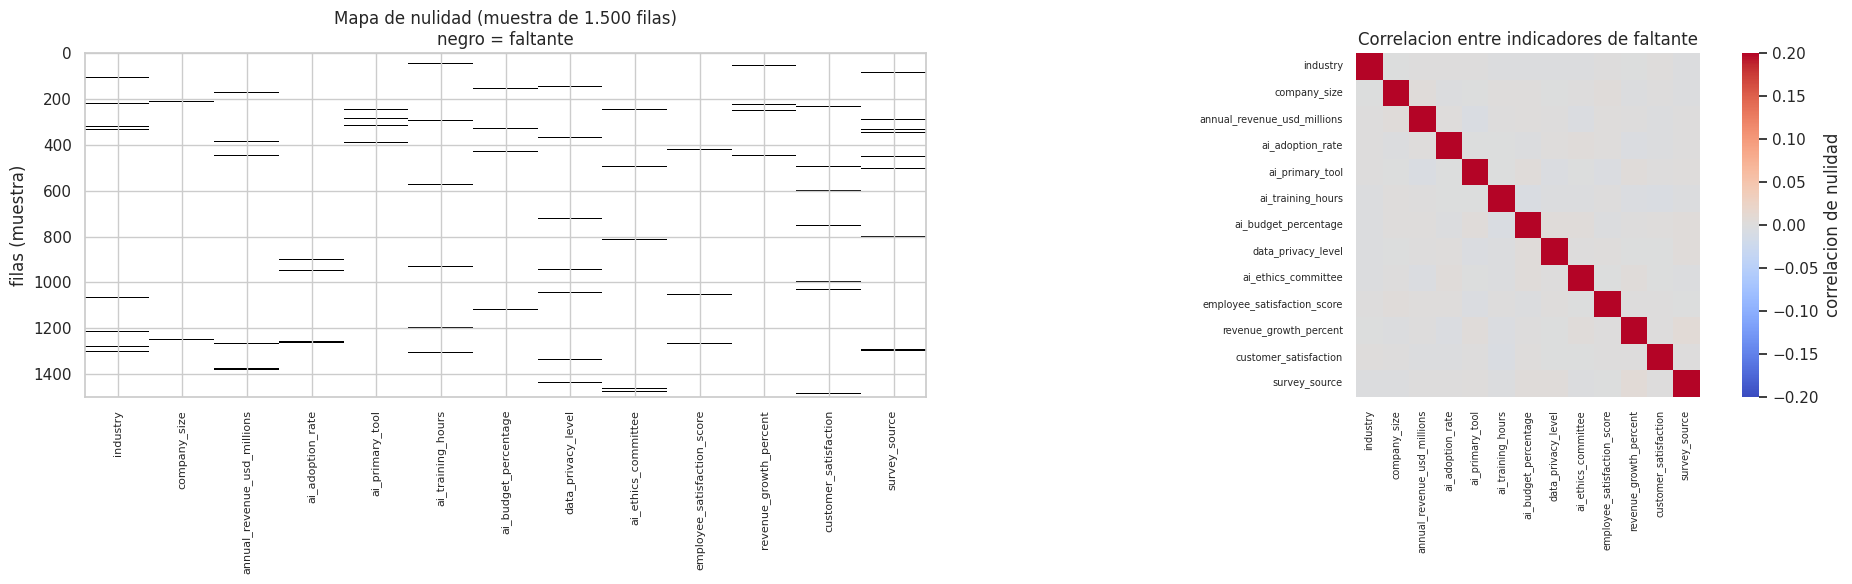

Correlacion de nulidad maxima (fuera de la diagonal): 0.0069


In [ ]:
# --- Prueba 3: correlacion entre indicadores de nulidad + mapa de nulidad ---
fig, axes = plt.subplots(1, 2, figsize=(19, 6))

muestra = mascara_nula.sample(1500, random_state=42)
axes[0].imshow(~muestra.values, aspect="auto", cmap="gray", interpolation="nearest")
axes[0].set_xticks(range(len(cols_diagnostico)))
axes[0].set_xticklabels(cols_diagnostico, rotation=90, fontsize=8)
axes[0].set_title("Mapa de nulidad (muestra de 1.500 filas)\nnegro = faltante")
axes[0].set_ylabel("filas (muestra)")

corr_nulidad = mascara_nula.corr()
sns.heatmap(corr_nulidad, cmap="coolwarm", center=0, vmin=-0.2, vmax=0.2,
            square=True, cbar_kws={"label": "correlacion de nulidad"}, ax=axes[1])
axes[1].set_title("Correlacion entre indicadores de faltante")
axes[1].tick_params(labelsize=7)

plt.tight_layout()
plt.show()

fuera_diagonal = corr_nulidad.where(~np.eye(len(corr_nulidad), dtype=bool))
print(f"Correlacion de nulidad maxima (fuera de la diagonal): {fuera_diagonal.abs().max().max():.4f}")

### Conclusión del diagnóstico: el faltante es MCAR

Las tres pruebas apuntan a lo mismo:

1. **Co-ocurrencia**: la cantidad de filas con 1, 2 o 3 variables nulas coincide con lo esperado bajo
   independencia (desvíos de pocos puntos porcentuales). Si hubiera encuestas fallidas completas, veríamos
   muchísimas más filas con varios faltantes simultáneos que las que predice el azar; si el relevamiento
   evitara faltantes múltiples, veríamos muchas menos.
2. **Estabilidad**: la tasa de faltantes es prácticamente idéntica entre trimestres y entre industrias
   (rango menor a 0,3 puntos porcentuales). No hay un período ni un sector con problemas de relevamiento.
3. **Correlación de nulidad**: todas las correlaciones fuera de la diagonal están cerca de cero. Que falte
   una variable no dice nada sobre si falta otra.

**Es MCAR a nivel celda**: el faltante se comporta como ruido aleatorio de carga, sin relación con el valor
de la variable ni con ninguna otra. Esto habilita a imputar sin introducir sesgo sistemático, y descarta la
opción de tratar el faltante como información (por ejemplo, con una categoría "no responde", que sí tendría
sentido bajo MNAR).

### 2.4 Evaluación de estrategias

Con el mecanismo diagnosticado, evaluamos las tres alternativas del enunciado contra el caso concreto:

| Estrategia | Costo en este dataset | Cuándo la usamos |
|---|---|---|
| **Eliminar la variable** | Perderíamos variables centrales para las preguntas (`revenue_growth_percent` es directamente un target). Con 1,5% de faltante es desproporcionado. | Sólo para las que además se descartan por otras razones (sección 5). |
| **Eliminar las filas** | Como los faltantes son independientes entre sí, un `dropna()` sobre las 20 variables elimina **26.735 filas (17,8%)**, no el 1,5% que uno esperaría intuitivamente. Es el efecto acumulativo de faltantes independientes. | Descartada. |
| **Imputar** | Reduce levemente la varianza, pero conserva las 150.000 filas. Bajo MCAR no sesga las estimaciones. | **Elegida**, con un criterio distinto según el tipo de variable. |

El argumento decisivo contra la eliminación de filas es cuantitativo y conviene mostrarlo:

In [ ]:
filas_completas = df_final[cols_faltantes].notnull().all(axis=1).sum()
print(f"Filas sin ningun faltante: {filas_completas:,} de {len(df_final):,}")
print(f"Perdida por dropna() sobre las 20 variables: "
      f"{len(df_final) - filas_completas:,} filas ({(1 - filas_completas/len(df_final))*100:.1f}%)")
print("\nA pesar de que ninguna variable individual supera el 1,5% de faltantes.")

Filas sin ningun faltante: 123,265 de 150,000
Perdida por dropna() sobre las 20 variables: 26,735 filas (17.8%)

A pesar de que ninguna variable individual supera el 1,5% de faltantes.


Ahora bien, "imputar" no es una sola estrategia. La estructura de panel abre una opción mucho mejor que el
estadístico global: **usar los otros trimestres de la misma empresa**. Para saber cuándo eso es válido hay
que distinguir qué variables son atributos estables de la empresa y cuáles cambian entre trimestres.

In [ ]:
candidatas_fijas = ["industry", "country", "region", "company_size", "company_age_group",
                    "data_privacy_level", "ai_ethics_committee", "ai_primary_tool"]

n_empresas = df_final["company_id"].nunique()
estabilidad = []
for col in candidatas_fijas:
    valores_distintos = df_final.groupby("company_id")[col].nunique()
    inestables = int((valores_distintos > 1).sum())
    estabilidad.append({
        "variable": col,
        "empresas_con_mas_de_1_valor": inestables,
        "%_inestables": round(inestables / n_empresas * 100, 1),
    })

estabilidad = pd.DataFrame(estabilidad).sort_values("%_inestables")
display(estabilidad)

,variable,empresas_con_mas_de_1_valor,%_inestables
0,industry,0,0.000
1,country,0,0.000
2,region,0,0.000
3,company_size,0,0.000
4,company_age_group,2759,27.600
6,ai_ethics_committee,9990,99.900
5,data_privacy_level,9999,100.000
7,ai_primary_tool,10000,100.000


El resultado separa las variables en tres regímenes bien distintos:

- **Fijas (0% de inestabilidad)** — `industry`, `country`, `region`, `company_size`: ninguna empresa cambia
  de valor en 16 trimestres. Son atributos estructurales. Un faltante acá se **recupera**, no se imputa:
  copiamos el valor que la propia empresa reportó en cualquier otro trimestre.
- **Evolutiva (27,6%)** — `company_age_group`: cambia en algunas empresas, pero de forma **monótona** (una
  empresa pasa de "6-15 años" a "16-30 años" con el paso del tiempo, nunca al revés). No es ruido, es el
  paso del tiempo.
- **Ruidosas (99,9%–100%)** — `data_privacy_level`, `ai_ethics_committee`, `ai_primary_tool`: cambian de valor
  en prácticamente todas las empresas entre trimestres. Que el 100% de las empresas "cambie de herramienta
  principal de IA" todos los trimestres no describe una evolución real: es **variabilidad de medición**
  (cambia quién responde la encuesta o cómo se releva el dato). Acá no tiene sentido copiar el valor del
  trimestre anterior, porque ese valor es tan arbitrario como el que falta.

Para las variables **numéricas** MCAR aplicamos la misma lógica que a las fijas pero con un estadístico
robusto: la **mediana intra-empresa**. Una empresa con 15 observaciones válidas de `ai_budget_percentage` da
una estimación mucho mejor de su presupuesto típico que la mediana global de las 10.000 empresas, que
ignoraría por completo la heterogeneidad entre ellas. Usamos mediana y no media por la asimetría que
detectamos en el P1.

### 2.5 Implementación

**a) Variables fijas** — recuperación desde la propia empresa (`ffill` + `bfill` dentro de `company_id`).

In [ ]:
fijas = ["industry", "country", "region", "company_size"]

nulos_antes = df_final[fijas].isnull().sum()
for col in fijas:
    df_final[col] = df_final.groupby("company_id")[col].transform(lambda s: s.ffill().bfill())

print(pd.DataFrame({"nulos_antes": nulos_antes,
                    "nulos_despues": df_final[fijas].isnull().sum()}))

              nulos_antes  nulos_despues
industry             2250              0
country                 0              0
region                  0              0
company_size         2250              0


**b) Columnas de contexto (`avg_*`)** — no se imputan: se **rehace la unión**.

Como ya explicamos en la sección 1, estas columnas estaban vacías únicamente porque `industry` estaba
vacía. Ahora que recuperamos la industria real de cada empresa, volver a unir con `df2` recupera el
promedio sectorial **correcto**, en lugar de inventar uno.

In [ ]:
cols_avg = [c for c in df_final.columns if c.startswith("avg_")]
print(f"Nulos en columnas avg_* antes: {df_final[cols_avg].isnull().sum().sum():,}")

df_final = df_final.drop(columns=cols_avg).merge(df2, on="industry", how="left", validate="m:1")

print(f"Nulos en columnas avg_* despues: {df_final[cols_avg].isnull().sum().sum()}")
print(f"Filas: {len(df_final):,} (el merge no debe cambiarlas)")

Nulos en columnas avg_* antes: 15,750
Nulos en columnas avg_* despues: 0
Filas: 150,000 (el merge no debe cambiarlas)


**c) Numéricas MCAR** — mediana intra-empresa, con la mediana global sólo como red de seguridad para
empresas sin ningún dato válido en esa columna.

In [ ]:
numericas_mcar = ["ai_adoption_rate", "annual_revenue_usd_millions", "revenue_growth_percent",
                  "employee_satisfaction_score", "ai_training_hours",
                  "ai_budget_percentage", "customer_satisfaction"]

registro_imputacion = []
for col in numericas_mcar:
    n_inicial = df_final[col].isnull().sum()
    df_final[col] = df_final[col].fillna(df_final.groupby("company_id")[col].transform("median"))
    n_tras_empresa = df_final[col].isnull().sum()
    if n_tras_empresa > 0:
        df_final[col] = df_final[col].fillna(df_final[col].median())
    registro_imputacion.append({
        "variable": col,
        "nulos_iniciales": n_inicial,
        "imputados_con_mediana_de_su_empresa": n_inicial - n_tras_empresa,
        "imputados_con_mediana_global": n_tras_empresa,
    })

display(pd.DataFrame(registro_imputacion))

,variable,nulos_iniciales,imputados_con_mediana_de_su_empresa,imputados_con_mediana_global
0,ai_adoption_rate,2248,2248,0
1,annual_revenue_usd_millions,2247,2247,0
2,revenue_growth_percent,2246,2246,0
3,employee_satisfaction_score,2247,2247,0
4,ai_training_hours,2248,2248,0
5,ai_budget_percentage,2250,2250,0
6,customer_satisfaction,2250,2250,0


El detalle importante del cuadro: **el 100% de los faltantes se resolvió con información de la propia
empresa**; no hizo falta recurrir ni una sola vez a la mediana global. Era esperable en un panel donde cada
empresa tiene ~16 observaciones y la probabilidad de faltante es 1,5%, pero conviene dejarlo verificado.

**d) Categóricas ruidosas** — moda intra-empresa (el valor que esa empresa reportó más veces), que captura
su estado "típico" sin depender de un trimestre puntual arbitrario. Si una empresa no tuviera ningún valor
válido, usamos una categoría explícita `"Desconocido"` en lugar de inventar una respuesta.

In [ ]:
ruidosas = ["data_privacy_level", "ai_ethics_committee", "ai_primary_tool"]

for col in ruidosas:
    n_inicial = df_final[col].isnull().sum()
    moda_empresa = df_final.groupby("company_id")[col].transform(
        lambda s: s.mode().iloc[0] if not s.mode().empty else np.nan)
    df_final[col] = df_final[col].fillna(moda_empresa)
    restantes = df_final[col].isnull().sum()
    if restantes > 0:
        df_final[col] = df_final[col].fillna("Desconocido")
    print(f"{col:22s}: {n_inicial:>5,} nulos -> {n_inicial - restantes:,} por moda de la empresa, "
          f"{restantes} como 'Desconocido'")

data_privacy_level    : 2,250 nulos -> 2,250 por moda de la empresa, 0 como 'Desconocido'


ai_ethics_committee   : 2,250 nulos -> 2,250 por moda de la empresa, 0 como 'Desconocido'


ai_primary_tool       : 2,250 nulos -> 2,250 por moda de la empresa, 0 como 'Desconocido'


**e) `survey_source`** — caso aparte. No es un atributo de la empresa sino **metadata de cómo se recolectó
esa encuesta puntual**. Copiarla de otro trimestre supondría que la empresa siempre se releva por la misma
fuente, algo que no verificamos y que no tiene por qué ser cierto. Como es 1,5% y MCAR, imputamos con la
categoría `"Desconocido"`, que además deja trazabilidad de qué filas tienen fuente real.
(De todas formas esta variable se descarta en la sección 5 por ser metadata del relevamiento y no un
atributo de la empresa.)

In [ ]:
df_final["survey_source"] = df_final["survey_source"].fillna("Desconocido")
print(df_final["survey_source"].value_counts())

survey_source
LinkedIn Poll                37138
Internal Corporate Survey    37055
McKinsey Report              36921
WEF Survey                   36636
Desconocido                   2250
Name: count, dtype: int64


### 2.6 Verificación

Dos chequeos: que no quede ningún faltante, y —más importante— que la imputación **no haya deformado las
distribuciones**. Comparamos los estadísticos antes y después contra `df_pre_imputacion`.

In [ ]:
print(f"Celdas nulas en df_final: {df_final.isnull().sum().sum()}")
print(f"Variables con algun nulo: {(df_final.isnull().sum() > 0).sum()}\n")

comparacion = []
for col in numericas_mcar:
    antes, despues = df_pre_imputacion[col], df_final[col]
    comparacion.append({
        "variable": col,
        "media_antes": antes.mean(), "media_despues": despues.mean(),
        "mediana_antes": antes.median(), "mediana_despues": despues.median(),
        "std_antes": antes.std(), "std_despues": despues.std(),
        "%_cambio_std": (despues.std() / antes.std() - 1) * 100,
    })

display(pd.DataFrame(comparacion).round(3))

Celdas nulas en df_final: 0
Variables con algun nulo: 0



,variable,media_antes,media_despues,mediana_antes,mediana_despues,std_antes,std_despues,%_cambio_std
0,ai_adoption_rate,36.432,36.431,36.330,36.330,15.417,15.362,-0.361
1,annual_revenue_usd_millions,"1,177.235","1,177.427",184.140,184.140,"2,588.947","2,585.989",-0.114
2,revenue_growth_percent,4.619,4.617,4.480,4.480,5.741,5.706,-0.620
3,employee_satisfaction_score,5.647,5.646,5.600,5.600,2.361,2.344,-0.736
4,ai_training_hours,27.246,27.244,27.070,27.070,13.931,13.861,-0.498
5,ai_budget_percentage,9.510,9.510,9.430,9.430,3.837,3.822,-0.413
6,customer_satisfaction,5.420,5.420,5.410,5.410,1.047,1.041,-0.601


Las medianas quedan **idénticas** y las medias cambian en el tercer o cuarto decimal. El desvío estándar
baja entre 0,3% y 0,7%, que es exactamente el efecto esperado y conocido de cualquier imputación por
estadístico central: al reemplazar valores desconocidos por el centro de su grupo, se elimina la variabilidad
que esos valores habrían aportado.

Es un costo aceptable —y muy inferior al de perder el 17,8% de las filas—, pero **queda anotado como
limitación**: los intervalos de confianza y los errores estándar del Práctico 3 estarán levemente
subestimados sobre estas siete variables. Una alternativa que evaluamos y descartamos por complejidad
desproporcionada frente al 1,5% de faltante es la imputación múltiple (MICE), que sí propaga esa
incertidumbre.

---
## 3. Outliers

Un valor extremo puede ser tres cosas muy distintas, y cada una pide un tratamiento diferente:

- un **error** (dato imposible o mal cargado) → hay que corregirlo o eliminarlo;
- un **caso extremo válido** (una empresa que realmente es enorme) → hay que conservarlo, porque es
  información;
- un caso **ambiguo** → hay que documentar la incertidumbre y elegir la opción conservadora.

Por eso no alcanza con un solo criterio estadístico. Aplicamos tres, en orden creciente de ambigüedad:

1. **Rangos lógicos de dominio**: valores que son imposibles por definición de la variable.
2. **Consistencia interna del panel**: valores que contradicen lo que la misma empresa reporta en otros
   trimestres.
3. **Criterio estadístico (Tukey, 1,5×IQR)**: valores lejanos al cuerpo de la distribución, que después hay
   que interpretar cruzándolos con otras variables.

### 3.1 Criterio 1 — Rangos lógicos

Definimos para cada variable el rango que puede tomar **por definición**, no por su distribución empírica:
un conteo de empleados no puede ser negativo, un porcentaje de adopción tiene que estar entre 0 y 100, un
puntaje de satisfacción declarado en escala 1–10 no puede valer 103. Estas violaciones son errores con
certeza, independientemente de cuán frecuentes sean.

In [ ]:
limites_logicos = {
    # No pueden ser negativas (conteos, montos, horas)
    "num_employees": (0, None),
    "annual_revenue_usd_millions": (0, None),
    "ai_investment_per_employee": (0, None),
    "ai_training_hours": (0, None),
    "jobs_displaced": (0, None),
    "jobs_created": (0, None),
    "reskilled_employees": (0, None),
    "time_saved_per_week": (0, None),
    "years_using_ai": (0, None),
    "ai_projects_active": (0, None),
    "num_ai_tools_used": (0, None),
    # Porcentajes y puntajes en escala 0-100
    "ai_adoption_rate": (0, 100),
    "ai_budget_percentage": (0, 100),
    "remote_work_percentage": (0, 100),
    "task_automation_rate": (0, 100),
    "ai_failure_rate": (0, 100),
    "ai_risk_management_score": (0, 100),
    "regulatory_compliance_score": (0, 100),
    "innovation_score": (0, 100),
    # Indices y puntajes en otras escalas
    "ai_maturity_score": (0, 1),            # indice normalizado
    "employee_satisfaction_score": (0, 10), # escala de satisfaccion, igual que customer_satisfaction
    "customer_satisfaction": (0, 10),
}

filas = []
for col, (minimo, maximo) in limites_logicos.items():
    viol_min = int((df_final[col] < minimo).sum()) if minimo is not None else 0
    viol_max = int((df_final[col] > maximo).sum()) if maximo is not None else 0
    filas.append({"variable": col, "lim_min": minimo, "lim_max": maximo,
                  "viol_min": viol_min, "viol_max": viol_max,
                  "min_observado": df_final[col].min(), "max_observado": df_final[col].max()})

resumen_logico = pd.DataFrame(filas)
violaciones = resumen_logico[resumen_logico[["viol_min", "viol_max"]].sum(axis=1) > 0]
print(f"Variables con valores fuera de rango logico: {len(violaciones)} de {len(resumen_logico)}\n")
display(violaciones.round(2))

Variables con valores fuera de rango logico: 5 de 22



,variable,lim_min,lim_max,viol_min,viol_max,min_observado,max_observado
1,annual_revenue_usd_millions,0,NaN,160,0,"-27,463.790","29,767.690"
2,ai_investment_per_employee,0,NaN,152,0,"-962,812.210","1,898,315.750"
3,ai_training_hours,0,NaN,146,0,-129.870,183.190
11,ai_adoption_rate,0,100.000,150,150,-138.000,210.120
20,employee_satisfaction_score,0,10.000,140,147,-4.160,103.830


Cinco variables tienen valores imposibles, todas con una magnitud parecida (~150 casos por lado, ≈0,1% del
dataset), lo que sugiere un mismo mecanismo de corrupción en la carga y no un problema conceptual de la
variable.

Antes de decidir el tratamiento vale la pena preguntarse si el dato es **recuperable**. La hipótesis más
económica para un valor negativo es un **error de signo**: el número sería correcto y sólo se guardó
invertido. Es testeable con la estructura de panel: si es un error de signo, el valor absoluto debería
parecerse a lo que esa misma empresa reporta en los trimestres válidos, es decir la razón
|valor| / mediana de la empresa debería concentrarse alrededor de 1.

In [ ]:
def diagnostico_recuperabilidad(df, col, lim_min, lim_max=None):
    """Compara los valores fuera de rango contra la mediana de la propia empresa
    en los trimestres validos, para evaluar si el dato es recuperable."""
    validos = df[col].where(df[col].between(lim_min, lim_max if lim_max is not None else np.inf))
    mediana_empresa = validos.groupby(df["company_id"]).transform("median")
    fuera = ~df[col].between(lim_min, lim_max if lim_max is not None else np.inf)
    razon = (df.loc[fuera, col].abs() / mediana_empresa[fuera]).dropna()
    return {
        "variable": col,
        "n_fuera_de_rango": int(fuera.sum()),
        "sin_referencia_de_empresa": int(mediana_empresa[fuera].isnull().sum()),
        "razon_p25": razon.quantile(0.25), "razon_mediana": razon.median(),
        "razon_p75": razon.quantile(0.75), "razon_max": razon.max(),
    }

casos = [("annual_revenue_usd_millions", 0, None), ("ai_investment_per_employee", 0, None),
         ("ai_training_hours", 0, None), ("ai_adoption_rate", 0, 100),
         ("employee_satisfaction_score", 0, 10)]

diagnostico = pd.DataFrame([diagnostico_recuperabilidad(df_final, c, lo, hi) for c, lo, hi in casos])
print("Razon = |valor fuera de rango| / mediana de la MISMA empresa en trimestres validos")
print("Cerca de 1 => el numero es plausible y solo esta mal el signo (recuperable)\n")
display(diagnostico.round(2))

Razon = |valor fuera de rango| / mediana de la MISMA empresa en trimestres validos
Cerca de 1 => el numero es plausible y solo esta mal el signo (recuperable)



,variable,n_fuera_de_rango,sin_referencia_de_empresa,razon_p25,razon_mediana,razon_p75,razon_max
0,annual_revenue_usd_millions,160,0,35.460,114.640,612.390,"6,753.220"
1,ai_investment_per_employee,152,0,8.860,16.270,28.620,423.290
2,ai_training_hours,146,0,0.800,1.380,3.280,9.100
3,ai_adoption_rate,300,0,1.840,3.220,4.520,51.470
4,employee_satisfaction_score,287,0,0.130,1.930,16.520,21.410


El test separa los casos con claridad:

- **`ai_training_hours` — error de signo recuperable.** La razón tiene mediana 1,38 y su rango intercuartil
  va de 0,8 a 3,3: el valor absoluto está en el mismo orden de magnitud que lo que la empresa reporta
  habitualmente. Es compatible con "el número es correcto, se guardó invertido". **Tratamiento: invertir el
  signo**, que recupera el dato real sin necesidad de imputar nada.

- **`annual_revenue_usd_millions` e `ai_investment_per_employee` — no recuperables.** La razón tiene mediana
  115× y 16× respectivamente, con casos de hasta 6.753×. Si sólo fuera el signo, el valor absoluto debería
  parecerse al histórico de la empresa; en cambio es dos o tres órdenes de magnitud mayor. Invertir el signo
  no devuelve un dato creíble: devuelve un número igualmente imposible, pero positivo.

- **`ai_adoption_rate` y `employee_satisfaction_score` — no recuperables.** Tampoco hay una transformación
  simple que los rescate: probamos además restar la escala (por ejemplo, ver si los valores >100 fueran el
  valor real + 100) y las razones siguen siendo dispersas y sin patrón.

**Tratamiento para los cuatro casos no recuperables:** convertirlos en faltantes y aplicarles el **mismo
criterio de imputación de la sección 2** (mediana intra-empresa). Es coherente con lo ya hecho: un valor
imposible no es más informativo que un valor ausente, y ya validamos que el resto de las observaciones de la
empresa es una buena referencia. La alternativa de eliminar esas ~750 filas se descarta porque eliminaría
observaciones cuyo resto de variables es perfectamente válido.

In [ ]:
registro_outliers = []

# --- a) Error de signo recuperable: ai_training_hours ---
mascara = df_final["ai_training_hours"] < 0
n = int(mascara.sum())
df_final.loc[mascara, "ai_training_hours"] = df_final.loc[mascara, "ai_training_hours"].abs()
registro_outliers.append({"variable": "ai_training_hours", "criterio": "rango logico",
                          "diagnostico": "error de signo (recuperable)",
                          "tratamiento": "valor absoluto", "n_filas": n})
print(f"ai_training_hours: {n} valores corregidos por signo | negativos restantes: "
      f"{(df_final['ai_training_hours'] < 0).sum()}")

ai_training_hours: 146 valores corregidos por signo | negativos restantes: 0


In [ ]:
# --- b) No recuperables: se marcan como faltantes y se imputan con el criterio de la seccion 2 ---
no_recuperables = {"annual_revenue_usd_millions": (0, None),
                   "ai_investment_per_employee": (0, None),
                   "ai_adoption_rate": (0, 100),
                   "employee_satisfaction_score": (0, 10)}

for col, (lo, hi) in no_recuperables.items():
    fuera = ~df_final[col].between(lo, hi if hi is not None else np.inf)
    n = int(fuera.sum())
    df_final.loc[fuera, col] = np.nan
    df_final[col] = df_final[col].fillna(df_final.groupby("company_id")[col].transform("median"))
    n_global = int(df_final[col].isnull().sum())
    if n_global:
        df_final[col] = df_final[col].fillna(df_final[col].median())
    registro_outliers.append({"variable": col, "criterio": "rango logico",
                              "diagnostico": "valor imposible, no recuperable",
                              "tratamiento": "a faltante + mediana intra-empresa", "n_filas": n})
    print(f"{col:30s}: {n:>4} valores imputados "
          f"({n_global} necesitaron mediana global) | rango final: "
          f"[{df_final[col].min():,.2f} , {df_final[col].max():,.2f}]")

annual_revenue_usd_millions   :  160 valores imputados (0 necesitaron mediana global) | rango final: [1.01 , 29,767.69]
ai_investment_per_employee    :  152 valores imputados (0 necesitaron mediana global) | rango final: [0.00 , 1,898,315.75]
ai_adoption_rate              :  300 valores imputados (0 necesitaron mediana global) | rango final: [0.00 , 100.00]
employee_satisfaction_score   :  287 valores imputados (0 necesitaron mediana global) | rango final: [0.05 , 9.20]


El efecto del tratamiento se ve mejor en `employee_satisfaction_score`: antes tenía una asimetría de 35,8
provocada por 75 valores alrededor de 103 en una escala de 1 a 10; después queda en ≈0,0. Un solo puñado de
valores imposibles bastaba para deformar por completo la distribución de la variable.

### 3.2 Criterio 2 — Consistencia interna del panel

Este criterio no busca valores raros en la distribución, sino valores que **contradicen la definición de la
variable**. `annual_revenue_usd_millions` son los ingresos *anuales* de la empresa: dentro de un mismo año
calendario, los cuatro trimestres deberían reportar el mismo número. Si no lo hacen, hay un error de carga
que ningún método basado en la distribución global detectaría, porque el valor puede ser perfectamente
normal en términos absolutos.

In [ ]:
por_anio = df_final.groupby(["company_id", "survey_year"])["annual_revenue_usd_millions"]
variacion = por_anio.agg(["min", "max", "mean"])
variacion["rango_relativo"] = (variacion["max"] - variacion["min"]) / variacion["mean"]

UMBRAL = 0.05   # hasta 5% de variacion intra-anio se considera estable
inconsistentes = variacion[variacion["rango_relativo"] > UMBRAL]

print(f"Combinaciones empresa-anio: {len(variacion):,}")
print(f"Con variacion intra-anio > {UMBRAL:.0%}: {len(inconsistentes)} "
      f"({len(inconsistentes)/len(variacion)*100:.2f}%)\n")
print("Magnitud de la variacion en los casos inconsistentes:")
display(inconsistentes["rango_relativo"].describe().round(2).to_frame().T)

Combinaciones empresa-anio: 39,999
Con variacion intra-anio > 5%: 139 (0.35%)

Magnitud de la variacion en los casos inconsistentes:


,count,mean,std,min,25%,50%,75%,max
rango_relativo,139.000,3.420,0.840,0.850,3.000,3.790,3.970,4.000


El 99,65% de las combinaciones empresa-año tiene **variación exactamente cero**, lo que confirma que la
variable es efectivamente anual. Los 139 casos inconsistentes no varían un poco: varían en promedio un
**342%** dentro del mismo año. No es ruido de medición, es un trimestre con el valor mal cargado.

**Tratamiento:** reemplazar el valor discrepante por la **moda del año de esa empresa** (el valor que
reportan los otros tres trimestres). A diferencia de una imputación, acá no estimamos nada: el dato correcto
está literalmente en las filas vecinas.

In [ ]:
moda_anual = df_final.groupby(["company_id", "survey_year"])["annual_revenue_usd_millions"].transform(
    lambda s: s.mode().iloc[0] if not s.mode().empty else np.nan)

desvio = (df_final["annual_revenue_usd_millions"] - moda_anual).abs() / moda_anual
a_corregir = desvio > UMBRAL
n = int(a_corregir.sum())
df_final.loc[a_corregir, "annual_revenue_usd_millions"] = moda_anual[a_corregir]

registro_outliers.append({"variable": "annual_revenue_usd_millions", "criterio": "consistencia intra-anio",
                          "diagnostico": "error de carga puntual",
                          "tratamiento": "moda del anio de la empresa", "n_filas": n})

# Verificacion
v2 = df_final.groupby(["company_id", "survey_year"])["annual_revenue_usd_millions"].agg(["min", "max", "mean"])
v2["rango_relativo"] = (v2["max"] - v2["min"]) / v2["mean"]
print(f"Filas corregidas: {n}")
print(f"Combinaciones empresa-anio inconsistentes despues de corregir: {(v2['rango_relativo'] > UMBRAL).sum()}")

Filas corregidas: 140
Combinaciones empresa-anio inconsistentes despues de corregir: 0


### 3.3 Criterio 3 — Tukey (1,5 × IQR)

Recién ahora, con los errores de definición ya resueltos, aplicamos el criterio estadístico sobre todas las
numéricas. A diferencia de los dos anteriores, **este criterio no distingue error de caso extremo válido**:
sólo marca lo que está lejos del cuerpo de la distribución. Por eso lo usamos como detector, no como
decisor.

In [ ]:
def outliers_iqr(serie):
    q1, q3 = serie.quantile([0.25, 0.75])
    iqr = q3 - q1
    return (serie < q1 - 1.5 * iqr) | (serie > q3 + 1.5 * iqr)

excluir = (["response_id", "survey_year", "company_founding_year", "company_age"]
           + [c for c in df_final.columns if c.startswith("avg_")])
numericas = [c for c in df_final.select_dtypes(include=[np.number]).columns if c not in excluir]

filas = []
for col in numericas:
    serie = df_final[col].dropna()
    marcados = outliers_iqr(serie)
    filas.append({"variable": col, "asimetria": serie.skew(),
                  "n_outliers": int(marcados.sum()),
                  "%_outliers": marcados.sum() / len(serie) * 100})

resumen_iqr = pd.DataFrame(filas).sort_values("%_outliers", ascending=False)
display(resumen_iqr.head(15).round(2))

,variable,asimetria,n_outliers,%_outliers
1,annual_revenue_usd_millions,2.280,27947,18.630
0,num_employees,2.280,27894,18.600
19,jobs_created,2.790,27697,18.460
20,reskilled_employees,2.990,26980,17.990
18,jobs_displaced,3.030,26622,17.750
10,ai_investment_per_employee,4.490,12160,8.110
28,ai_patent_filings_2024,2.540,9735,6.490
4,num_ai_tools_used,0.310,1587,1.060
14,employee_satisfaction_score,-0.010,1119,0.750
24,customer_satisfaction,0.050,978,0.650


**Cómo leemos esta tabla.** Bajo el criterio de Tukey, una distribución normal produce ~0,7% de outliers
*por construcción*: marcar valores no significa que haya un problema. Fijamos entonces un **umbral del 1%**:
por debajo lo tomamos como variabilidad esperada y no intervenimos; por encima, investigamos la causa.

Con ese umbral quedan ocho variables por revisar, y cinco se resuelven sin análisis adicional:

- `jobs_created`, `reskilled_employees`, `jobs_displaced` (17–18%): son **conteos absolutos**, así que su
  asimetría (≈3,0) refleja el tamaño de las empresas, no un problema de calidad. En la sección 3.5 las
  reemplazamos por tasas relativas a `num_employees`, que es la forma correcta de usarlas para nuestras
  preguntas; las versiones absolutas no entran al modelado.
- `ai_patent_filings_2024` (6,5%): es una variable **de país** replicada en 150.000 filas. Su distribución
  refleja que China y EE.UU. tienen órdenes de magnitud más patentes que el resto, algo que ya analizamos en
  el P1 a nivel país. No es un outlier a nivel empresa.
- `num_ai_tools_used` (1,06%): es un conteo discreto que va de 1 a 6. Lo que el IQR marca son simplemente
  los valores 5 y 6, que son categorías legítimas y poco frecuentes, no valores anómalos. El criterio de
  Tukey no está pensado para variables discretas con tan pocos valores posibles.

Quedan tres para analizar en serio: **`num_employees`**, **`annual_revenue_usd_millions`** y
**`ai_investment_per_employee`**.

#### ¿Los valores extremos son errores o empresas realmente grandes?

La forma de distinguirlos es cruzar los outliers con una variable que los explique. Si los valores extremos
de `num_employees` correspondieran a empresas de cualquier tamaño declarado, serían sospechosos; si
correspondieran todos a empresas categorizadas como *Enterprise*, serían coherentes.

In [ ]:
def perfil_outliers(df, col, dimension):
    marcados = outliers_iqr(df[col])
    tabla = pd.DataFrame({
        "%_entre_outliers": df.loc[marcados, dimension].value_counts(normalize=True) * 100,
        "%_en_el_dataset": df[dimension].value_counts(normalize=True) * 100,
    })
    tabla["sobre_representacion"] = tabla["%_entre_outliers"] / tabla["%_en_el_dataset"]
    return tabla.fillna(0).sort_values("%_entre_outliers", ascending=False).round(2)

for col in ["num_employees", "annual_revenue_usd_millions"]:
    print(f"===== {col} — outliers segun company_size =====")
    display(perfil_outliers(df_final, col, "company_size"))

===== num_employees — outliers segun company_size =====


,%_entre_outliers,%_en_el_dataset,sobre_representacion
company_size,,,
Enterprise,100.000,19.630,5.090
SME,0.000,42.580,0.000
Startup,0.000,37.790,0.000


===== annual_revenue_usd_millions — outliers segun company_size =====


,%_entre_outliers,%_en_el_dataset,sobre_representacion
company_size,,,
Enterprise,100.000,19.630,5.090
SME,0.000,42.580,0.000
Startup,0.000,37.790,0.000


In [ ]:
print("===== ai_investment_per_employee — outliers segun company_size =====")
display(perfil_outliers(df_final, "ai_investment_per_employee", "company_size"))
print("===== ai_investment_per_employee — outliers segun industry =====")
display(perfil_outliers(df_final, "ai_investment_per_employee", "industry"))

===== ai_investment_per_employee — outliers segun company_size =====


,%_entre_outliers,%_en_el_dataset,sobre_representacion
company_size,,,
SME,39.220,42.580,0.920
Enterprise,33.510,19.630,1.710
Startup,27.270,37.790,0.720


===== ai_investment_per_employee — outliers segun industry =====


,%_entre_outliers,%_en_el_dataset,sobre_representacion
industry,,,
Technology,19.480,14.070,1.380
Finance,14.340,13.440,1.070
Healthcare,11.700,12.430,0.940
Retail,10.340,10.920,0.950
Manufacturing,10.070,11.670,0.860
Agriculture,9.760,10.380,0.940
Education,9.330,10.110,0.920
Logistics,8.070,8.640,0.930
Consulting,6.900,8.340,0.830


**`num_employees` y `annual_revenue_usd_millions` → casos extremos válidos, se conservan.**

El **100%** de los outliers de ambas variables corresponde a empresas *Enterprise*, cuando esa categoría
representa apenas el 19,6% del dataset. La categoría explica los outliers por completo: no son errores, son
las empresas grandes de la muestra. Eliminarlas o recortarlas sería peor que inútil, sería **contraproducente**
para nuestras preguntas de investigación: justamente queremos saber si el efecto de la IA sobre el empleo y
los ingresos depende del tamaño de la empresa, y estaríamos sacando el extremo de esa variable.

**`ai_investment_per_employee` → caso ambiguo, tratamiento conservador.**

Acá ninguna categoría explica los outliers. Hay sobre-representación parcial de Technology (19,5% vs 14,1%)
y Finance, consistente con que esos sectores inviertan relativamente más en IA, pero `company_size` no
muestra un patrón claro y el resto de las industrias aparece en proporciones cercanas a las esperadas.

Es una mezcla probable de dinámica sectorial real y ruido residual, y **no tenemos evidencia para separarlas**.
Decisión: **no eliminar ni recortar**, y documentar la incertidumbre. El razonamiento es de costo asimétrico:
si son válidos y los recortamos, perdemos justo las empresas que más invierten en IA, que son el núcleo de la
pregunta de rentabilidad; si son ruido y los conservamos, degradan algo el ajuste pero no invalidan el
análisis. Queda anotado para el P3 que esta variable conviene usarla **en escala logarítmica** o con modelos
robustos a colas pesadas.

### 3.4 Hallazgo adicional: punto de masa en `revenue_growth_percent`

Al inspeccionar la variable que va a ser **target** de la primera pregunta de investigación apareció algo que
ningún criterio de outliers detecta, porque no es un valor extremo sino un valor *repetido*.

In [ ]:
conteo = df_final["revenue_growth_percent"].round(2).value_counts()
print("Valores mas repetidos de revenue_growth_percent:")
display(conteo.head(5).to_frame("n_filas"))

en_el_piso = df_final["revenue_growth_percent"] == -5.0
print(f"\nFilas con valor exactamente -5.00: {en_el_piso.sum():,} ({en_el_piso.mean()*100:.2f}%)")
print(f"Filas por debajo de -5.00.........: {(df_final['revenue_growth_percent'] < -5).sum():,}")
print(f"Filas por encima de -5.00.........: {(df_final['revenue_growth_percent'] > -5).sum():,}")

print("\nPerfil de las empresas en el piso vs el resto:")
display(df_final.groupby(en_el_piso)[["ai_adoption_rate", "ai_budget_percentage",
                                      "productivity_change_percent"]].mean().round(2)
        .rename(index={False: "resto", True: "en el piso (-5)"}))

Valores mas repetidos de revenue_growth_percent:


,n_filas
revenue_growth_percent,
-5.000,5985
4.060,145
5.560,138
3.650,134
2.720,133



Filas con valor exactamente -5.00: 5,985 (3.99%)
Filas por debajo de -5.00.........: 138
Filas por encima de -5.00.........: 143,877

Perfil de las empresas en el piso vs el resto:


,ai_adoption_rate,ai_budget_percentage,productivity_change_percent
revenue_growth_percent,,,
resto,36.890,9.610,9.520
en el piso (-5),25.110,7.090,4.350


El 3,99% de las observaciones (5.985 filas) tiene el valor **exactamente −5,00**, y sólo 138 caen por debajo. No es un
outlier: es un **piso de censura**. La variable parece estar truncada por abajo, de modo que todas las
empresas que habrían caído por debajo de −5% quedan apiladas en ese valor. El perfil lo respalda: las
empresas en el piso tienen adopción de IA sistemáticamente menor (25,1 vs 36,9 de media) y menos presupuesto
de IA (7,1% vs 9,6%).

Esto **no se corrige** —no hay forma de recuperar el valor verdadero de una observación censurada— pero es
crítico para el P3, porque afecta directamente al target de la pregunta 1: una regresión lineal sobre una
variable censurada subestima sistemáticamente el efecto de los predictores en la cola inferior.

**Decisión:** conservar la variable tal cual y agregar un **indicador explícito** `revenue_growth_censurado`
(que marca el piso y las pocas observaciones por debajo, 4,1% en total), para que el modelado del P3 pueda
tratar el caso —excluyendo esas filas, o usando un modelo para datos censurados tipo Tobit— en lugar de
ignorar el problema.

In [ ]:
df_final["revenue_growth_censurado"] = (df_final["revenue_growth_percent"] <= -5.0).astype("int8")
print(df_final["revenue_growth_censurado"].value_counts(normalize=True).round(4))

revenue_growth_censurado
0   0.959
1   0.041
Name: proportion, dtype: float64


### 3.5 Variables derivadas: de conteos absolutos a tasas

Quedó pendiente del P1 la normalización de las variables de empleo. `jobs_displaced`, `jobs_created` y
`reskilled_employees` son conteos absolutos, así que están dominados por el tamaño de la empresa: una
Enterprise que desplaza 200 puestos sobre 15.000 empleados tiene un impacto relativo mucho menor que una
Startup que desplaza 20 sobre 50.

Como la pregunta de investigación es sobre el **impacto de la IA en la fuerza laboral**, la magnitud
relevante es la tasa, no el conteo. Las construimos ahora, ya sobre datos limpios, y creamos también el
**saldo neto** que es el target de la segunda pregunta.

In [ ]:
vars_empleo = ["jobs_displaced", "jobs_created", "reskilled_employees"]

for col in vars_empleo:
    df_final[f"{col}_rate"] = df_final[col] / df_final["num_employees"]

df_final["jobs_net_balance_rate"] = df_final["jobs_created_rate"] - df_final["jobs_displaced_rate"]

comparacion = pd.DataFrame({
    "asimetria_absoluta": df_final[vars_empleo].skew(),
    "asimetria_como_tasa": [df_final[f"{c}_rate"].skew() for c in vars_empleo],
    "%_outliers_absoluta": [outliers_iqr(df_final[c]).mean() * 100 for c in vars_empleo],
    "%_outliers_como_tasa": [outliers_iqr(df_final[f"{c}_rate"]).mean() * 100 for c in vars_empleo],
}).round(2)
display(comparacion)

print("\nDistribucion del saldo neto (jobs_net_balance_rate):")
display(df_final["jobs_net_balance_rate"].describe().round(4).to_frame().T)

,asimetria_absoluta,asimetria_como_tasa,%_outliers_absoluta,%_outliers_como_tasa
jobs_displaced,3.030,0.100,17.750,0.290
jobs_created,2.790,-0.020,18.460,0.420
reskilled_employees,2.990,0.160,17.990,0.360



Distribucion del saldo neto (jobs_net_balance_rate):


,count,mean,std,min,25%,50%,75%,max
jobs_net_balance_rate,"150,000.000",0.001,0.021,-0.106,-0.012,0.000,0.014,0.100


La normalización resuelve el problema de raíz: la asimetría cae de ≈3,0 a ≈0,0 y la proporción de outliers
por IQR pasa de 17–18% a menos de 0,5%. Confirma la lectura de la sección 3.3: **esos "outliers" no eran
errores ni casos extremos raros, eran un artefacto de medir en unidades absolutas** una magnitud que es
relativa por naturaleza.

A partir de acá, las versiones absolutas quedan fuera del modelado y usamos las tasas.

### 3.6 Resumen de decisiones sobre outliers

In [ ]:
registro_outliers += [
    {"variable": "num_employees", "criterio": "IQR (Tukey)",
     "diagnostico": "caso extremo valido (100% Enterprise)",
     "tratamiento": "se conserva sin cambios", "n_filas": int(outliers_iqr(df_final["num_employees"]).sum())},
    {"variable": "annual_revenue_usd_millions", "criterio": "IQR (Tukey)",
     "diagnostico": "caso extremo valido (100% Enterprise)",
     "tratamiento": "se conserva sin cambios",
     "n_filas": int(outliers_iqr(df_final["annual_revenue_usd_millions"]).sum())},
    {"variable": "ai_investment_per_employee", "criterio": "IQR (Tukey)",
     "diagnostico": "ambiguo (sin categoria que lo explique)",
     "tratamiento": "se conserva; usar en escala log en el P3",
     "n_filas": int(outliers_iqr(df_final["ai_investment_per_employee"]).sum())},
    {"variable": "jobs_displaced / jobs_created / reskilled_employees", "criterio": "IQR (Tukey)",
     "diagnostico": "artefacto de escala (conteos absolutos)",
     "tratamiento": "reemplazadas por tasas sobre num_employees", "n_filas": None},
    {"variable": "revenue_growth_percent", "criterio": "inspeccion de la distribucion",
     "diagnostico": "censura a la izquierda en -5.00",
     "tratamiento": "se conserva + flag revenue_growth_censurado",
     "n_filas": int((df_final["revenue_growth_percent"] <= -5).sum())},
]

display(pd.DataFrame(registro_outliers))

,variable,criterio,diagnostico,tratamiento,n_filas
0,ai_training_hours,rango logico,error de signo (recuperable),valor absoluto,146.000
1,annual_revenue_usd_millions,rango logico,"valor imposible, no recuperable",a faltante + mediana intra-empresa,160.000
2,ai_investment_per_employee,rango logico,"valor imposible, no recuperable",a faltante + mediana intra-empresa,152.000
3,ai_adoption_rate,rango logico,"valor imposible, no recuperable",a faltante + mediana intra-empresa,300.000
4,employee_satisfaction_score,rango logico,"valor imposible, no recuperable",a faltante + mediana intra-empresa,287.000
5,annual_revenue_usd_millions,consistencia intra-anio,error de carga puntual,moda del anio de la empresa,140.000
6,num_employees,IQR (Tukey),caso extremo valido (100% Enterprise),se conserva sin cambios,"27,894.000"
7,annual_revenue_usd_millions,IQR (Tukey),caso extremo valido (100% Enterprise),se conserva sin cambios,"27,947.000"
8,ai_investment_per_employee,IQR (Tukey),ambiguo (sin categoria que lo explique),se conserva; usar en escala log en el P3,"12,160.000"
9,jobs_displaced / jobs_created / reskilled_empl...,IQR (Tukey),artefacto de escala (conteos absolutos),reemplazadas por tasas sobre num_employees,NaN


---
## 4. Variables categóricas

La decisión sobre cada categórica (codificar, agrupar o descartar) depende de tres cosas: si tiene un
**orden** intrínseco, su **cardinalidad**, y si describe a la **empresa** o al **relevamiento**.

In [ ]:
# El periodo (anio-trimestre) se necesita como variable ordenada; se construye aca
df_final["periodo"] = (df_final["survey_year"].astype(int).astype(str) + "-" + df_final["quarter"])

categoricas = df_final.select_dtypes(include="object").columns.tolist()
inventario = pd.DataFrame({
    "n_categorias": df_final[categoricas].nunique(),
    "categoria_mas_frecuente": [df_final[c].mode().iloc[0] for c in categoricas],
    "%_categoria_mas_frecuente": [df_final[c].value_counts(normalize=True).iloc[0] * 100 for c in categoricas],
}).sort_values("n_categorias")
display(inventario.round(1))

,n_categorias,categoria_mas_frecuente,%_categoria_mas_frecuente
ai_ethics_committee,2,No,59.200
company_size,3,SME,42.600
data_privacy_level,3,High,43.500
country_ai_policy,3,Moderate,56.500
data_collection_method,4,Research Compilation,25.100
quarter,4,Q4,25.000
company_age_group,4,16-30 years,45.600
ai_adoption_stage,4,partial,52.500
survey_source,5,LinkedIn Poll,24.800
ai_primary_tool,6,ChatGPT,31.200


### 4.1 Verificación empírica del orden

Tratar una variable como ordinal es una afirmación sobre los datos, no una intuición sobre los nombres de
las categorías. Antes de asignar códigos numéricos verificamos que el orden que vamos a imponer **existe en
los datos**.

In [ ]:
print("company_size vs num_employees (los rangos no deberian solaparse):")
display(df_final.groupby("company_size")["num_employees"].agg(["min", "max", "count"]))

print("\nai_adoption_stage vs ai_adoption_rate (la mediana deberia crecer con la etapa):")
display(df_final.groupby("ai_adoption_stage")["ai_adoption_rate"].agg(["median", "count"]).round(2))

print("\ncompany_age_group vs company_age (los tramos deberian ser contiguos):")
display(df_final.groupby("company_age_group")["company_age"].agg(["min", "max", "count"]))

company_size vs num_employees (los rangos no deberian solaparse):


,min,max,count
company_size,,,
Enterprise,"1,010.000","19,970.000",29448
SME,100.000,999.000,63867
Startup,10.000,99.000,56685



ai_adoption_stage vs ai_adoption_rate (la mediana deberia crecer con la etapa):


,median,count
ai_adoption_stage,,
full,73.340,1685
none,5.850,5198
partial,45.090,78800
pilot,26.460,64317



company_age_group vs company_age (los tramos deberian ser contiguos):


,min,max,count
company_age_group,,,
0-5 years,1.000,5.000,15372
16-30 years,16.000,30.000,68383
30+ years,31.000,36.000,20253
6-15 years,6.000,15.000,45992


Los tres órdenes quedan confirmados empíricamente:

- **`company_size`**: los rangos de empleados no se solapan en absoluto (Startup 10–99, SME 100–999,
  Enterprise 1.010–19.970). El orden Startup < SME < Enterprise no es una convención, es una partición
  determinística de `num_employees` — dato que vamos a reutilizar en la sección 5.
- **`ai_adoption_stage`**: la mediana de adopción crece monótonamente (none 5,8 → pilot 26,4 → partial 45,2
  → full 73,4). El orden refleja una progresión real.
- **`company_age_group`**: los tramos son contiguos y exhaustivos sobre `company_age`.

`data_privacy_level` (Low < Medium < High) y `country_ai_policy` (Lenient < Moderate < Strict) tienen orden
semántico explícito en el propio nombre de las categorías, así que no requieren verificación empírica.

### 4.2 `quarter` y `periodo`: ¿estacionalidad o tendencia?

`quarter` sólo tiene sentido como variable estacional si el patrón se **repite** todos los años. Si en
cambio los valores crecen de forma continua a lo largo del panel sin reiniciarse en cada Q1, entonces
`quarter` no está capturando una estación: está capturando el paso del tiempo, y la variable correcta es el
período completo.

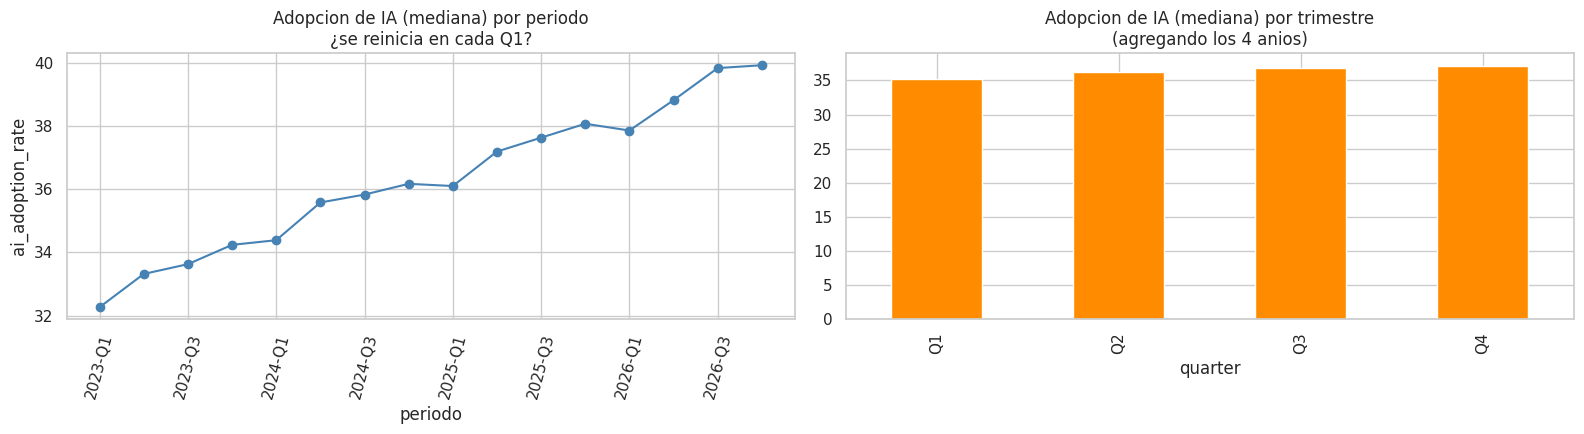

Cambio de Q4 al Q1 del anio siguiente (si hubiera estacionalidad anual, deberia caer al nivel inicial):
periodo
2024-Q1    0.150
2025-Q1   -0.070
2026-Q1   -0.210

Salto medio entre trimestres dentro del anio: +0.65 puntos
Salto medio de Q4 a Q1..................... : -0.05 puntos
Recorrido total de la serie (2023-Q1 a 2026-Q4): +7.65 puntos


In [ ]:
tendencia = df_final.groupby("periodo")["ai_adoption_rate"].median()

fig, axes = plt.subplots(1, 2, figsize=(16, 4.5))
tendencia.plot(marker="o", ax=axes[0], color="steelblue")
axes[0].set_title("Adopcion de IA (mediana) por periodo\n¿se reinicia en cada Q1?")
axes[0].set_xlabel("periodo"); axes[0].set_ylabel("ai_adoption_rate")
axes[0].tick_params(axis="x", rotation=75)

df_final.groupby("quarter")["ai_adoption_rate"].median().plot(kind="bar", ax=axes[1], color="darkorange")
axes[1].set_title("Adopcion de IA (mediana) por trimestre\n(agregando los 4 anios)")
axes[1].set_xlabel("quarter")
plt.tight_layout(); plt.show()

saltos = tendencia.diff().dropna()
saltos_q1 = saltos[saltos.index.str.endswith("Q1")]    # cambio de Q4 al Q1 del anio siguiente
saltos_resto = saltos[~saltos.index.str.endswith("Q1")]

print("Cambio de Q4 al Q1 del anio siguiente (si hubiera estacionalidad anual, deberia caer al nivel inicial):")
print(saltos_q1.round(2).to_string())
print(f"\nSalto medio entre trimestres dentro del anio: {saltos_resto.mean():+.2f} puntos")
print(f"Salto medio de Q4 a Q1..................... : {saltos_q1.mean():+.2f} puntos")
print(f"Recorrido total de la serie (2023-Q1 a 2026-Q4): {tendencia.iloc[-1] - tendencia.iloc[0]:+.2f} puntos")

La serie **sube a lo largo de los 16 trimestres y no se reinicia**: gana casi 8 puntos entre 2023-Q1 y
2026-Q4, y el paso de un Q4 al Q1 siguiente es prácticamente nulo (entre +0,15 y −0,21 puntos) frente a un
avance medio de +0,65 puntos entre trimestres dentro del año. Es decir, cada año arranca donde terminó el
anterior. Si hubiera estacionalidad, el Q1 volvería al nivel del Q1 previo y veríamos una caída de varios
puntos.

El aparente "efecto trimestre" del gráfico de la derecha es la misma tendencia vista de costado: los Q4
promedian más alto sólo porque acumulan los años más avanzados.

**Decisión:** descartar `quarter` como categórica y reemplazarla por **`periodo_encoded`**, un índice
secuencial 0–15 que preserva el orden cronológico exacto y permite modelar la tendencia como una variable
continua, con una sola columna en lugar de cuatro dummies sin significado propio.

### 4.3 Decisiones por variable

| Variable | Categorías | Naturaleza | Decisión | Justificación |
|---|---|---|---|---|
| `ai_ethics_committee` | 2 | binaria | codificar 0/1 | Con dos categorías, One-Hot generaría una columna redundante |
| `data_privacy_level` | 3 | ordinal | ordinal encoding | Orden semántico explícito (Low < Medium < High) |
| `country_ai_policy` | 3 | ordinal | ordinal encoding | Mide intensidad regulatoria; orden natural |
| `company_size` | 3 | ordinal | ordinal encoding | Orden verificado: rangos de empleados sin solapamiento |
| `ai_adoption_stage` | 4 | ordinal | ordinal encoding | Orden verificado contra `ai_adoption_rate` |
| `company_age_group` | 4 | ordinal | ordinal encoding | Tramos contiguos verificados sobre `company_age` |
| `region` | 6 | nominal | One-Hot | Sin orden; cardinalidad baja |
| `ai_primary_tool` | 6 | nominal | One-Hot | Sin orden; cardinalidad baja (se revisa su utilidad en la sección 5) |
| `ai_use_case` | 8 | nominal | One-Hot | Sin orden; es central para la pregunta 2 (¿importa el *tipo* de uso de IA?) |
| `industry` | 9 | nominal | One-Hot | Sin orden; cardinalidad manejable |
| `country` | 30 | nominal, alta cardinalidad | **descartar** | 30 columnas nuevas; su información está en `region` + los indicadores numéricos de `df3` |
| `quarter` | 4 | temporal cíclica | **descartar** | Verificado: no hay estacionalidad, sólo tendencia (§4.2) |
| `periodo` | 16 | temporal secuencial | índice 0–15 | One-Hot sería excesivo y perdería el orden |
| `survey_source` | 4 (+ `Desconocido`) | metadata | **descartar** | Describe cómo se relevó la encuesta, no a la empresa |
| `data_collection_method` | 4 | metadata | **descartar** | Ídem |
| `company_id` | 10.000 | identificador | no se codifica | Es la clave de agrupación; se conserva como índice, nunca como predictor |

Dos aclaraciones sobre las decisiones menos obvias:

- **No agrupamos categorías.** Es una opción razonable cuando hay categorías raras (por ejemplo, juntar en
  "Otros" las que aparecen en menos del 1%), pero acá todas las nominales están razonablemente balanceadas:
  la categoría menos frecuente de `industry` es Consulting con 8,3%. Agrupar sólo perdería información.
- **`ai_primary_tool` se codifica pero queda bajo sospecha.** En la sección 2 vimos que cambia de valor en el
  100% de las empresas entre trimestres, o sea que se comporta como ruido de medición. La codificamos para
  poder evaluarla, pero su valor predictivo es dudoso y lo revisamos en la sección 5.

In [ ]:
# --- 1. Ordinales (mapeo manual explicito) ---
mapeos_ordinales = {
    "data_privacy_level": {"Low": 0, "Medium": 1, "High": 2},
    "country_ai_policy": {"Lenient": 0, "Moderate": 1, "Strict": 2},
    "ai_adoption_stage": {"none": 0, "pilot": 1, "partial": 2, "full": 3},
    "company_age_group": {"0-5 years": 0, "6-15 years": 1, "16-30 years": 2, "30+ years": 3},
    "company_size": {"Startup": 0, "SME": 1, "Enterprise": 2},
}
for col, mapeo in mapeos_ordinales.items():
    df_final[f"{col}_encoded"] = df_final[col].map(mapeo)

# --- 2. Binaria ---
df_final["ai_ethics_committee_encoded"] = df_final["ai_ethics_committee"].map({"No": 0, "Yes": 1})

# --- 3. Temporal secuencial ---
orden_periodos = sorted(df_final["periodo"].unique())
df_final["periodo_encoded"] = df_final["periodo"].map({p: i for i, p in enumerate(orden_periodos)})

# --- Verificacion: ningun mapeo debe generar nulos (categoria no contemplada) ---
nuevas = [f"{c}_encoded" for c in mapeos_ordinales] + ["ai_ethics_committee_encoded", "periodo_encoded"]
control = df_final[nuevas].isnull().sum()
print("Nulos generados por los mapeos (deben ser todos 0):")
print(control.to_string())
assert control.sum() == 0, "Hay categorias sin mapear"

Nulos generados por los mapeos (deben ser todos 0):
data_privacy_level_encoded     0
country_ai_policy_encoded      0
ai_adoption_stage_encoded      0
company_age_group_encoded      0
company_size_encoded           0
ai_ethics_committee_encoded    0
periodo_encoded                0


In [ ]:
# --- 4. Nominales: One-Hot ---
cols_one_hot = ["industry", "region", "ai_use_case", "ai_primary_tool"]
df_final = pd.get_dummies(df_final, columns=cols_one_hot, prefix=cols_one_hot, dtype="int8")

# --- 5. Descarte de categoricas sin uso para el modelado ---
a_descartar = ["survey_source", "data_collection_method", "country", "quarter"]
df_final = df_final.drop(columns=[c for c in a_descartar if c in df_final.columns])

nuevas_dummies = [c for c in df_final.columns if any(c.startswith(p + "_") for p in cols_one_hot)]
print(f"Columnas One-Hot creadas: {len(nuevas_dummies)}")
print(f"Columnas descartadas....: {a_descartar}")
print(f"Shape de df_final.......: {df_final.shape}")
print(f"Nulos en el dataset.....: {df_final.isnull().sum().sum()}")

Columnas One-Hot creadas: 29
Columnas descartadas....: ['survey_source', 'data_collection_method', 'country', 'quarter']
Shape de df_final.......: (150000, 90)
Nulos en el dataset.....: 0


Las categóricas originales en texto se **conservan junto a su versión codificada**. Es deliberado: el
Práctico 3 va a usar las columnas `_encoded`, pero mantener el texto permite leer resultados, agrupar y
graficar sin tener que traducir códigos. La selección final de la sección 5 se encarga de que sólo una de
las dos versiones entre al modelo.

---
## 5. Selección de variables

La selección se ordena por las dos preguntas de investigación del P1:

| Pregunta | Variable objetivo | Predictores que tienen sentido |
|---|---|---|
| 1. ¿Es rentable invertir en IA? | `revenue_growth_percent` (y como alternativas `cost_reduction_percent`, `productivity_change_percent`) | Intensidad de inversión, adopción, estructura de la empresa, contexto sectorial y de país |
| 2. ¿La IA destruye empleo neto? | `jobs_net_balance_rate` | Adopción y automatización, tipo de caso de uso, estructura de la empresa |

Aplicamos cuatro filtros sucesivos: **redundancia estructural**, **opacidad de construcción**,
**redundancia estadística** y **rol causal** (una variable puede ser un resultado y no un predictor).

### 5.1 Redundancia estructural: variables que son función exacta de otras

Antes de mirar correlaciones conviene detectar las redundancias que son **identidades matemáticas**. Una
correlación alta se puede discutir; una identidad no: la variable no aporta absolutamente nada.

In [ ]:
# a) company_age es una identidad: survey_year - company_founding_year
identidad = (df_final["company_age"] == df_final["survey_year"] - df_final["company_founding_year"])
print(f"company_age == survey_year - company_founding_year en el "
      f"{identidad.mean()*100:.2f}% de las filas")

# b) Las columnas avg_* son un promedio por industria: ¿las explica industry por completo?
cols_industry = [c for c in df_final.columns if c.startswith("industry_")]
cols_avg = [c for c in df_final.columns if c.startswith("avg_")]

def r2_contra(target, predictores, df):
    datos = df[predictores + [target]].dropna()
    return LinearRegression().fit(datos[predictores], datos[target]).score(datos[predictores], datos[target])

print("\nR2 de cada variable avg_* explicada UNICAMENTE por las dummies de industry:")
for col in cols_avg:
    print(f"  {col:35s} R2 = {r2_contra(col, cols_industry, df_final):.4f}")

company_age == survey_year - company_founding_year en el 100.00% de las filas

R2 de cada variable avg_* explicada UNICAMENTE por las dummies de industry:
  avg_ai_adoption_rate                R2 = 1.0000


  avg_productivity_change_percent     R2 = 1.0000
  avg_ai_maturity_score               R2 = 1.0000


  avg_ai_failure_rate                 R2 = 1.0000
  avg_jobs_displaced                  R2 = 1.0000


  avg_jobs_created                    R2 = 1.0000
  avg_customer_satisfaction           R2 = 1.0000


Dos redundancias totales confirmadas:

- **`company_age` = `survey_year` − `company_founding_year`** en el 100% de las filas. Las tres variables
  contienen exactamente la misma información. Conservamos sólo `company_age_group_encoded`, que es la
  versión discretizada y suficiente para el modelado (y ya verificamos en §4.1 que sus tramos son contiguos).
- **Las 7 columnas `avg_*` tienen R² = 1,0000 contra las dummies de `industry`.** Es esperable por
  construcción: son el promedio de cada métrica por industria, así que conocer la industria determina
  exactamente su valor. Mantenerlas junto a `industry` sería duplicar el mismo efecto en dos
  parametrizaciones distintas, lo que además genera colinealidad perfecta en un modelo lineal.

Lo mismo vale para **`company_size_encoded`**, que en §4.1 verificamos que es una partición determinística
de `num_employees`: conservamos la variable continua, que tiene más información.

### 5.2 Variables cuya construcción no es evidente

El dataset trae cinco puntajes compuestos (`ai_maturity_score`, `ai_failure_rate`,
`regulatory_compliance_score`, `ai_risk_management_score`, `innovation_score`) **sin documentación de cómo se
calculan**. Esto es exactamente el tipo de variable que el enunciado pide discutir, porque incluirlas sin
entenderlas tiene tres riesgos concretos:

1. **Fuga de información (*leakage*)**: si el puntaje se construyó a partir de la variable que queremos
   predecir, el modelo va a "acertar" por una vía circular y no va a generalizar.
2. **Redundancia encubierta**: si es una combinación de variables que ya tenemos, infla la colinealidad sin
   agregar señal.
3. **Interpretabilidad nula**: si el modelo dice que el puntaje es el predictor más importante, no podemos
   traducirlo en ninguna recomendación, porque no sabemos qué mide.

Lo tratable empíricamente es (1) y (2): medimos **qué proporción de cada puntaje se explica por variables que
ya tenemos**, con un R² contra sus correlatos más fuertes.

In [ ]:
scores_opacos = ["ai_maturity_score", "ai_failure_rate", "regulatory_compliance_score",
                 "ai_risk_management_score", "innovation_score"]

numericas = df_final.select_dtypes(include=[np.number]).columns.tolist()

diagnostico_scores = []
for score in scores_opacos:
    corr = df_final[numericas].corrwith(df_final[score]).drop(score).sort_values(key=abs, ascending=False)
    top5 = corr.head(5).index.tolist()
    diagnostico_scores.append({
        "score": score,
        "R2_explicado_por_sus_5_correlatos": round(r2_contra(score, top5, df_final), 3),
        "correlato_mas_fuerte": f"{corr.index[0]} (r={corr.iloc[0]:.2f})",
        "top_5_correlatos": ", ".join(top5),
    })

display(pd.DataFrame(diagnostico_scores))

,score,R2_explicado_por_sus_5_correlatos,correlato_mas_fuerte,top_5_correlatos
0,ai_maturity_score,0.984,ai_adoption_rate (r=0.84),"ai_adoption_rate, ai_budget_percentage, ai_pro..."
1,ai_failure_rate,0.576,ai_training_hours (r=-0.70),"ai_training_hours, ai_maturity_score, ai_adopt..."
2,regulatory_compliance_score,0.277,country_ai_policy_encoded (r=0.51),"country_ai_policy_encoded, digital_maturity_in..."
3,ai_risk_management_score,0.384,ai_ethics_committee_encoded (r=0.51),"ai_ethics_committee_encoded, ai_maturity_score..."
4,innovation_score,0.296,ai_maturity_score (r=0.53),"ai_maturity_score, ai_adoption_rate, jobs_crea..."


El resultado ordena las decisiones:

- **`ai_maturity_score` (R² = 0,984) → se descarta.** Es prácticamente una combinación lineal de
  `ai_budget_percentage`, `ai_projects_active`, `ai_adoption_rate` y `ai_training_hours`, todas variables
  que ya están en el dataset y que sí sabemos qué miden. No aporta información nueva y genera colinealidad
  casi perfecta.
- **`ai_failure_rate` (R² = 0,576) → se conserva.** Ni redundante ni completamente opaca: el 42% de su
  variación no lo explica ninguna variable disponible, y su vínculo con la pregunta de rentabilidad es
  directo (una inversión con alta tasa de fracaso rinde distinto). Se conserva **asumiendo el riesgo
  explícitamente**: si en el P3 aparece como predictor dominante, hay que sospechar leakage antes que
  celebrar el ajuste.
- **`regulatory_compliance_score` (0,277), `ai_risk_management_score` (0,384) e `innovation_score` (0,296)
  → se descartan.** No son redundantes, pero entre el 62% y el 72% de su variación no se explica con nada del
  dataset, o sea que **no sabemos qué están midiendo** y no tenemos forma de averiguarlo. Además ninguna
  conecta de manera directa con las dos preguntas planteadas. Priorizamos interpretabilidad sobre un
  eventual poder predictivo que no podríamos explicar.

La regla que aplicamos: **una variable opaca se conserva sólo si su aporte a la pregunta de investigación
justifica no poder explicar qué mide.** Se cumple para `ai_failure_rate` y no para las otras tres.

### 5.3 Variables de contexto geográfico

Las 5 variables de `df3` tienen el mismo problema estructural que las `avg_*`: son constantes dentro de cada
país. Pero acá la conclusión es distinta, y conviene mostrar por qué.

In [ ]:
cols_region = [c for c in df_final.columns if c.startswith("region_")]
cols_geo = ["gdp_per_capita", "internet_penetration", "digital_maturity_index",
            "ai_patent_filings_2024", "ai_researchers_per_million"]

print("R2 de cada variable de pais explicada solo por region:")
for col in cols_geo:
    print(f"  {col:30s} R2 = {r2_contra(col, cols_region, df_final):.3f}")

print("\nCorrelacion entre las variables de pais (a nivel pais, sin replicar filas):")
display(df3[cols_geo].corr().round(2))

R2 de cada variable de pais explicada solo por region:
  gdp_per_capita                 R2 = 0.629
  internet_penetration           R2 = 0.551
  digital_maturity_index         R2 = 0.529
  ai_patent_filings_2024         R2 = 0.379
  ai_researchers_per_million     R2 = 0.549

Correlacion entre las variables de pais (a nivel pais, sin replicar filas):


,gdp_per_capita,internet_penetration,digital_maturity_index,ai_patent_filings_2024,ai_researchers_per_million
gdp_per_capita,1.000,0.850,0.860,0.400,0.930
internet_penetration,0.850,1.000,0.830,0.290,0.840
digital_maturity_index,0.860,0.830,1.000,0.550,0.950
ai_patent_filings_2024,0.400,0.290,0.550,1.000,0.520
ai_researchers_per_million,0.930,0.840,0.950,0.520,1.000


A diferencia de las `avg_*` (R² = 1,0), `region` explica sólo entre el 38% y el 63% de estas variables: hay
**variación real entre países de una misma región** que `region` no captura. Es coherente con lo que vimos en
el P1 (la heterogeneidad de Asia, o China liderando en patentes sin liderar en PBI per cápita). Así que no
se descartan por redundancia con `region`.

El problema es otro: **están fuertemente correlacionadas entre sí**. `gdp_per_capita` correlaciona 0,93 con
`ai_researchers_per_million`, 0,86 con `digital_maturity_index` y 0,85 con `internet_penetration`. Las cuatro
miden esencialmente lo mismo: el nivel de desarrollo del país.

**Decisión:** conservar **una sola** como representante de ese eje, `gdp_per_capita`, por ser la más
directamente interpretable y la más plausible como factor de rentabilidad (pregunta 1).

**Caso aparte: `ai_patent_filings_2024`.** Es la única que *no* es redundante (correlaciona sólo 0,40 con
`gdp_per_capita`), así que aportaría información distinta. Aun así la descartamos, por una razón que no es
estadística: es un **conteo absoluto de patentes por país**, no normalizado por población ni por tamaño de la
economía. En la práctica separa a China y EE.UU. del resto, así que dentro del modelo funcionaría como una
variable indicadora de esos dos países disfrazada de variable continua. Si en el P3 quisiéramos usar la
capacidad de innovación nacional, la construcción correcta sería normalizarla por población, no usarla cruda.

### 5.4 Redundancia estadística entre las variables sobrevivientes

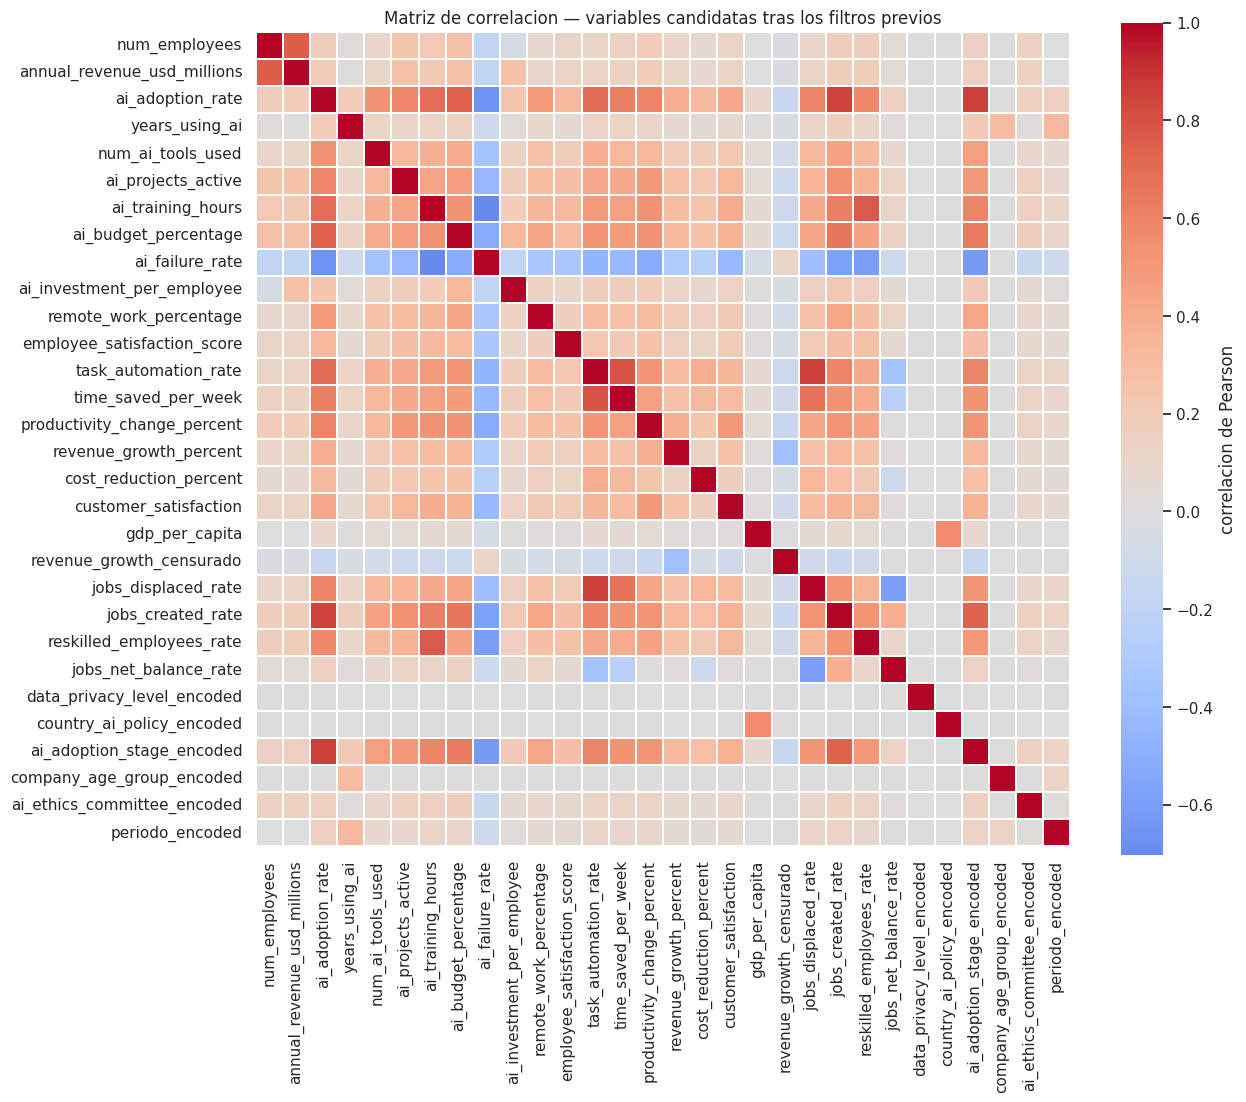

Pares con |r| >= 0.6 : 19


,variable_1,variable_2,r
7,ai_adoption_rate,ai_adoption_stage_encoded,0.856
15,task_automation_rate,jobs_displaced_rate,0.856
6,ai_adoption_rate,jobs_created_rate,0.848
14,task_automation_rate,time_saved_per_week,0.793
10,ai_training_hours,reskilled_employees_rate,0.771
0,num_employees,annual_revenue_usd_millions,0.748
2,ai_adoption_rate,ai_budget_percentage,0.740
18,jobs_created_rate,ai_adoption_stage_encoded,0.734
8,ai_training_hours,ai_failure_rate,-0.704
4,ai_adoption_rate,task_automation_rate,0.700


In [ ]:
descartes_previos = (
    [c for c in df_final.columns if c.startswith("avg_")] +
    ["internet_penetration", "digital_maturity_index", "ai_patent_filings_2024", "ai_researchers_per_million"] +
    ["ai_maturity_score", "regulatory_compliance_score", "ai_risk_management_score", "innovation_score"] +
    ["company_age", "company_founding_year", "survey_year", "company_size_encoded"] +
    ["response_id"] + ["jobs_displaced", "jobs_created", "reskilled_employees"]
)

candidatas = [c for c in df_final.select_dtypes(include=[np.number]).columns
              if c not in descartes_previos
              and not any(c.startswith(p) for p in ("industry_", "region_", "ai_use_case_", "ai_primary_tool_"))]

corr = df_final[candidatas].corr()

plt.figure(figsize=(13, 11))
sns.heatmap(corr, cmap="coolwarm", center=0, square=True, linewidths=0.3,
            cbar_kws={"label": "correlacion de Pearson"})
plt.title("Matriz de correlacion — variables candidatas tras los filtros previos")
plt.tight_layout(); plt.show()

pares = [{"variable_1": corr.columns[i], "variable_2": corr.columns[j], "r": round(corr.iloc[i, j], 3)}
         for i in range(len(corr)) for j in range(i + 1, len(corr)) if abs(corr.iloc[i, j]) >= 0.6]
print(f"Pares con |r| >= 0.6 : {len(pares)}")
display(pd.DataFrame(pares).sort_values("r", key=abs, ascending=False))

Los pares que quedan por encima de 0,6 **no son redundancias a eliminar**, sino relaciones sustantivas que
el modelado tiene que tener en cuenta. Los agrupamos:

- **Tamaño de la empresa**: `num_employees` ↔ `annual_revenue_usd_millions` (r ≈ 0,75). Son dos medidas del
  mismo constructo pero no intercambiables (una empresa puede tener muchos empleados y poca facturación).
  Conservamos las dos, anotando que en un modelo lineal conviene vigilar la colinealidad (VIF).
- **Intensidad de IA**: `ai_adoption_rate` ↔ `ai_adoption_stage_encoded` (r ≈ 0,86). La segunda es la
  versión categórica de la primera. Conservamos las dos porque la etapa aporta la no linealidad (el salto de
  *pilot* a *partial* puede importar más que 10 puntos de adopción), pero **no deberían entrar juntas a una
  regresión lineal simple**.
- **Automatización y empleo**: `task_automation_rate` ↔ `jobs_displaced_rate` (r ≈ 0,86). Esta es la más
  delicada y la discutimos abajo.

### 5.5 Rol causal: predictores vs. resultados

Este filtro no es estadístico y es el que más decisiones cambia. Varias variables del dataset no son
características de la empresa sino **consecuencias de haber adoptado IA**: `productivity_change_percent`,
`cost_reduction_percent`, `time_saved_per_week`, `customer_satisfaction`, `employee_satisfaction_score`.

Usarlas como predictores del crecimiento de ingresos daría un modelo con excelente ajuste y **sin ningún
valor**: estaríamos prediciendo un resultado a partir de otro resultado medido en el mismo momento. El modelo
respondería "las empresas a las que les fue bien en productividad también crecieron en ingresos", que no es
la pregunta.

Por eso las conservamos en el dataset pero **etiquetadas con su rol**, para que el P3 las use como targets
alternativos o como variables descriptivas, nunca como predictores del mismo período.

El caso de `task_automation_rate` merece mención aparte: correlaciona 0,86 con `jobs_displaced_rate`, que
forma parte del target de la pregunta 2. No es leakage estrictamente (la automatización antecede
conceptualmente al desplazamiento), pero está tan cerca del resultado que un modelo que la use va a explicar
el saldo neto casi por definición. Se conserva **porque es justamente la hipótesis a testear** —el P1 mostró
que automatización alta no implica saldo neto negativo—, pero el P3 debería reportar el modelo con y sin ella.

### 5.6 Catálogo final y dataset para el Práctico 3

In [ ]:
roles = {}

# Identificadores / trazabilidad
for c in ["company_id", "periodo", "periodo_encoded"]:
    roles[c] = ("identificador / temporal", "Trazabilidad y orden cronologico; periodo_encoded si puede usarse como tendencia")

# Objetivos
roles["revenue_growth_percent"] = ("objetivo", "Target de la pregunta 1 (rentabilidad); ojo con la censura en -5")
roles["revenue_growth_censurado"] = ("objetivo (auxiliar)", "Flag de censura del target de la pregunta 1")
roles["jobs_net_balance_rate"] = ("objetivo", "Target de la pregunta 2 (saldo neto de empleo, relativo al tamanio)")

# Resultados: no usar como predictores contemporaneos
for c in ["productivity_change_percent", "cost_reduction_percent", "time_saved_per_week",
          "customer_satisfaction", "employee_satisfaction_score",
          "jobs_created_rate", "jobs_displaced_rate", "reskilled_employees_rate"]:
    roles[c] = ("resultado", "Consecuencia de la adopcion de IA: target alternativo, no predictor contemporaneo")

# Predictores: inversion e intensidad de IA
for c in ["ai_adoption_rate", "ai_adoption_stage_encoded", "years_using_ai", "num_ai_tools_used",
          "ai_projects_active", "ai_training_hours", "ai_budget_percentage",
          "ai_investment_per_employee", "ai_failure_rate", "task_automation_rate"]:
    roles[c] = ("predictor - IA", "Intensidad y madurez de la adopcion de IA")

# Predictores: estructura de la empresa
for c in ["num_employees", "annual_revenue_usd_millions", "company_age_group_encoded",
          "remote_work_percentage", "data_privacy_level_encoded", "ai_ethics_committee_encoded"]:
    roles[c] = ("predictor - empresa", "Caracteristica estructural o de gobernanza de la empresa")

# Predictores: contexto
for c in df_final.columns:
    if c.startswith(("industry_", "region_", "ai_use_case_", "ai_primary_tool_")):
        roles[c] = ("predictor - contexto (One-Hot)", "Sector, geografia o tipo de uso de IA")
for c in ["gdp_per_capita", "country_ai_policy_encoded"]:
    roles[c] = ("predictor - contexto", "Nivel de desarrollo y marco regulatorio del pais")

catalogo = pd.DataFrame([{"variable": v, "rol": r[0], "justificacion": r[1]} for v, r in roles.items()])
print(catalogo["rol"].value_counts().to_string())
display(catalogo[~catalogo["rol"].str.contains("One-Hot")])

rol
predictor - contexto (One-Hot)    29
predictor - IA                    10
resultado                          8
predictor - empresa                6
identificador / temporal           3
objetivo                           2
predictor - contexto               2
objetivo (auxiliar)                1


,variable,rol,justificacion
0,company_id,identificador / temporal,Trazabilidad y orden cronologico; periodo_enco...
1,periodo,identificador / temporal,Trazabilidad y orden cronologico; periodo_enco...
2,periodo_encoded,identificador / temporal,Trazabilidad y orden cronologico; periodo_enco...
3,revenue_growth_percent,objetivo,Target de la pregunta 1 (rentabilidad); ojo co...
4,revenue_growth_censurado,objetivo (auxiliar),Flag de censura del target de la pregunta 1
5,jobs_net_balance_rate,objetivo,"Target de la pregunta 2 (saldo neto de empleo,..."
6,productivity_change_percent,resultado,Consecuencia de la adopcion de IA: target alte...
7,cost_reduction_percent,resultado,Consecuencia de la adopcion de IA: target alte...
8,time_saved_per_week,resultado,Consecuencia de la adopcion de IA: target alte...
9,customer_satisfaction,resultado,Consecuencia de la adopcion de IA: target alte...


In [ ]:
seleccionadas = [c for c in df_final.columns if c in roles]
descartadas = [c for c in df_final.columns if c not in roles]

df_modelado = df_final[seleccionadas].copy()

print(f"Variables conservadas: {len(seleccionadas)}")
print(f"Variables descartadas: {len(descartadas)}\n")
print("Descartadas en esta ultima pasada:")
print(", ".join(sorted(descartadas)))

print(f"\ndf_modelado: {df_modelado.shape[0]:,} filas x {df_modelado.shape[1]} columnas")
print(f"Nulos: {df_modelado.isnull().sum().sum()}")

Variables conservadas: 61
Variables descartadas: 29

Descartadas en esta ultima pasada:
ai_adoption_stage, ai_ethics_committee, ai_maturity_score, ai_patent_filings_2024, ai_researchers_per_million, ai_risk_management_score, avg_ai_adoption_rate, avg_ai_failure_rate, avg_ai_maturity_score, avg_customer_satisfaction, avg_jobs_created, avg_jobs_displaced, avg_productivity_change_percent, company_age, company_age_group, company_founding_year, company_size, company_size_encoded, country_ai_policy, data_privacy_level, digital_maturity_index, innovation_score, internet_penetration, jobs_created, jobs_displaced, regulatory_compliance_score, reskilled_employees, response_id, survey_year

df_modelado: 150,000 filas x 61 columnas
Nulos: 0


In [ ]:
# Verificacion final y exportacion
assert df_modelado.isnull().sum().sum() == 0, "Quedaron nulos"
assert not df_modelado.drop(columns=["company_id", "periodo"]).select_dtypes(include=[np.number]).isin(
    [np.inf, -np.inf]).any().any(), "Hay infinitos"
assert df_modelado.duplicated(subset=["company_id", "periodo"]).sum() == 0, "Se duplicaron filas"

df_modelado.to_csv("ai_workforce_curado.csv", index=False)
print("Dataset curado exportado como 'ai_workforce_curado.csv'")
display(df_modelado.head(3))

Dataset curado exportado como 'ai_workforce_curado.csv'


,company_id,num_employees,annual_revenue_usd_millions,ai_adoption_rate,years_using_ai,num_ai_tools_used,ai_projects_active,ai_training_hours,ai_budget_percentage,ai_failure_rate,ai_investment_per_employee,remote_work_percentage,employee_satisfaction_score,task_automation_rate,time_saved_per_week,productivity_change_percent,revenue_growth_percent,cost_reduction_percent,customer_satisfaction,gdp_per_capita,revenue_growth_censurado,jobs_displaced_rate,jobs_created_rate,reskilled_employees_rate,jobs_net_balance_rate,periodo,data_privacy_level_encoded,country_ai_policy_encoded,ai_adoption_stage_encoded,company_age_group_encoded,ai_ethics_committee_encoded,periodo_encoded,industry_Agriculture,industry_Consulting,industry_Education,industry_Finance,industry_Healthcare,industry_Logistics,industry_Manufacturing,industry_Retail,industry_Technology,region_Africa,region_Asia,region_Europe,region_North America,region_Oceania,region_South America,ai_use_case_Customer Support,ai_use_case_Fraud Detection,ai_use_case_HR Automation,ai_use_case_Marketing Automation,ai_use_case_Medical Diagnostics,ai_use_case_Predictive Maintenance,ai_use_case_Software Development,ai_use_case_Supply Chain Optimization,ai_primary_tool_ChatGPT,ai_primary_tool_Claude,ai_primary_tool_Custom Internal AI,ai_primary_tool_Gemini,ai_primary_tool_GitHub Copilot,ai_primary_tool_Other
0,COMP-00001,57.000,48.310,35.700,3.000,1.000,3.000,20.940,6.540,35.220,"55,392.290",14.550,6.950,19.470,6.440,2.650,2.520,9.450,5.200,"39,436.630",0,0.018,0.018,0.053,0.000,2023-Q1,1,1,1,2,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0
1,COMP-00001,57.000,48.310,27.250,4.000,3.000,0.000,23.100,5.810,24.650,"49,210.790",50.250,5.160,26.240,8.920,5.770,4.770,0.000,6.980,"39,436.630",0,0.035,0.035,0.088,0.000,2023-Q2,2,1,1,2,0,1,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0
2,COMP-00001,57.000,48.310,31.540,2.000,3.000,3.000,12.290,12.390,36.510,"105,011.760",41.700,4.570,22.240,7.590,6.940,12.870,9.740,4.120,"39,436.630",0,0.053,0.053,0.035,0.000,2023-Q3,2,1,1,2,0,2,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0


---
## 6. Conclusiones parciales

### Qué cambió

| Etapa | Punto de partida | Resultado |
|---|---|---|
| Integración | 3 archivos (150.025 × 43, 9 × 8, 30 × 8) | una tabla empresa × trimestre, 150.025 × 56 |
| Faltantes | 40 variables con nulos, 45.047 celdas vacías | 0 celdas nulas, sin perder filas |
| Outliers | 5 variables con valores imposibles + colas pesadas | errores corregidos, extremos válidos conservados |
| Categóricas | 16 variables de texto | 6 codificaciones ordinales/binarias + 29 dummies |
| Selección | 90 columnas tras el encoding | 61 variables, cada una con su rol asignado |

**Integración.** Se unió por `industry` y `country` con `left join` y `validate="m:1"`, previa verificación
de unicidad, cobertura y consistencia de `region` entre `df1` y `df3`. No se perdió ninguna fila y los únicos
registros sin match fueron los que ya tenían la clave nula, lo que determinó el orden de trabajo: primero
recuperar `industry`, después rehacer la unión.

**Faltantes.** Lo más útil fue no tratarlos como un problema homogéneo. Se separaron cuatro situaciones:
25 filas de prueba que concentraban el 100% de los faltantes aislados (eliminadas), faltantes heredados del
merge (resueltos rehaciendo la unión, no imputando), variables fijas de la empresa (recuperadas desde otros
trimestres) y variables MCAR (imputadas con la mediana intra-empresa, que alcanzó para el 100% de los casos
sin recurrir a la mediana global). El diagnóstico de MCAR se apoyó en tres pruebas convergentes en lugar de
la inspección visual sola.

**Outliers.** Se combinaron tres criterios y cada uno detectó un tipo distinto de problema: los rangos
lógicos encontraron ~750 valores imposibles, la consistencia intra-anual encontró 139 errores de carga que
ningún criterio distribucional habría marcado, y el IQR encontró colas pesadas que en su mayoría resultaron
ser información legítima. El test de recuperabilidad (razón contra la mediana de la propia empresa) permitió
separar el error de signo recuperable de la corrupción irreversible.

**Categóricas.** Todos los órdenes ordinales se verificaron contra los datos antes de codificarlos, y la
decisión sobre `quarter` se tomó después de comprobar que la serie no se reinicia entre años.

**Selección.** Se aplicaron cuatro filtros: identidades matemáticas, opacidad de construcción, redundancia
estadística y rol causal. El último fue el que más cambió el resultado, porque separó predictores de
resultados en un dataset donde muchas variables son consecuencias de la adopción de IA.

### Las decisiones más difíciles

1. **`ai_investment_per_employee`** — el único caso que no se pudo clasificar. Ninguna categoría explica sus
   outliers (a diferencia de `num_employees`, donde el 100% son *Enterprise*). Se optó por conservarlos y
   documentar la incertidumbre, con el argumento de costo asimétrico: recortarlos eliminaría justamente a las
   empresas que más invierten en IA, que son el centro de la pregunta 1.
2. **`ai_failure_rate` vs. los otros puntajes opacos** — con R² = 0,573 no cae claramente ni en "redundante"
   ni en "interpretable". Se conservó por su vínculo con la pregunta de rentabilidad, asumiendo el riesgo de
   forma explícita en vez de resolverlo con una regla automática.
3. **Distinguir predictores de resultados** — no hay ningún test que lo decida; depende enteramente de cómo
   se plantea la pregunta. Fue la decisión con más impacto sobre el conjunto final.
4. **Imputar vs. eliminar filas** — parecía una decisión menor con 1,5% de faltantes, hasta que el conteo
   mostró que un `dropna()` cuesta el 17,8% del dataset por el efecto acumulativo de faltantes independientes.

### Qué quedó listo, y con qué limitaciones

`ai_workforce_curado.csv` tiene 150.000 filas × grano empresa-trimestre, sin faltantes ni infinitos, con
todas las variables codificadas y con un rol asignado a cada una. Las dos preguntas del P1 tienen su target
construido: `revenue_growth_percent` (con su flag de censura) y `jobs_net_balance_rate`.

Tres advertencias que el Práctico 3 tiene que tener presentes:

- **La imputación redujo el desvío estándar entre 0,3% y 0,7%** en siete variables, así que los errores
  estándar van a estar levemente subestimados.
- **`revenue_growth_percent` está censurada a la izquierda** en −5,00 (4% de las observaciones). Una
  regresión lineal común va a subestimar el efecto de los predictores en la cola inferior.
- **`jobs_net_balance_rate` tiene un 18% de ceros exactos**, casi todos en empresas chicas donde la IA creó
  y desplazó la misma cantidad de puestos. La distribución del target no es continua alrededor del cero, así
  que conviene evaluar también una formulación por clases (destruye / neutro / crea).
- **El dataset es un panel, no una muestra de observaciones independientes.** Cada empresa aparece ~15 veces,
  así que un split aleatorio de train/test filtraría la misma empresa a ambos lados. El corte debe hacerse
  **por `company_id`** (o cronológicamente por `periodo_encoded`), y los modelos deberían considerar la
  estructura de panel.